# Code For "Optimal Abstractions for Verifying Properties of Kolmogorov-Arnold Networks (KANs)"

##### This is the companion notebook for the research paper "Optimal Abstractions for Verifying Properties of Kolmogorov-Arnold Networks (KANs)". It walks through the process of:
1. Training KANs (with ODEs and MNIST/CIFAR10)

2. Fitting linear segments to the network's B-Splines (using a vanilla method and a Dynamic Programming method)

3. Verifying the network with an MILP solver

4. Running the above steps repeatedly to generate the graphs used in the paper

In [8]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulp import (
    GUROBI_CMD, LpBinary, LpMaximize, LpMinimize, LpProblem, 
    LpStatus, LpVariable, lpSum
)
import scipy as sc
from sklearn.metrics import r2_score
from src.custom_fastkan import FastKAN, FastKANLayer
import src.kan_verification_grapher as kan_verification_grapher
import ssl
import time
from torch import autograd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from typing import List, Dict, Any, Tuple, Optional, Union

# Training KANs

We train KANs of different sizes on:
1. A Duffing Oscillator ODE, Dampened Pendulum ODE, and Lotka Volterra ODE.

2. The MNIST and CIFAR10 datasets.

Steps: 5
Dataset shape: torch.Size([250, 4])
Train dataset shape: torch.Size([225, 4]), Test dataset shape: torch.Size([25, 4])
Starting training...


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_6302/2002455832.py:81: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3729.)
  t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)


Iteration 0, Loss: 0.012464919127523899
Iteration 1, Loss: 0.003287028055638075
Iteration 2, Loss: 0.0018681450746953487
Iteration 3, Loss: 0.0010571988532319665
Iteration 4, Loss: 0.0006584307411685586

Test set predictions:


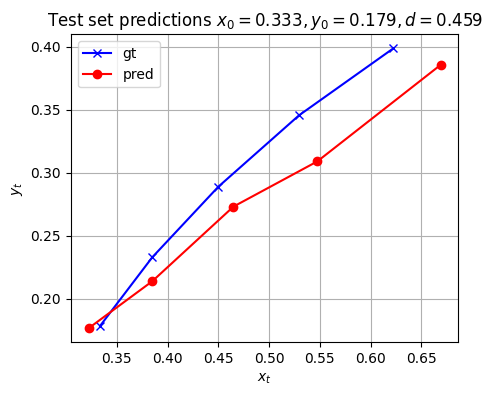

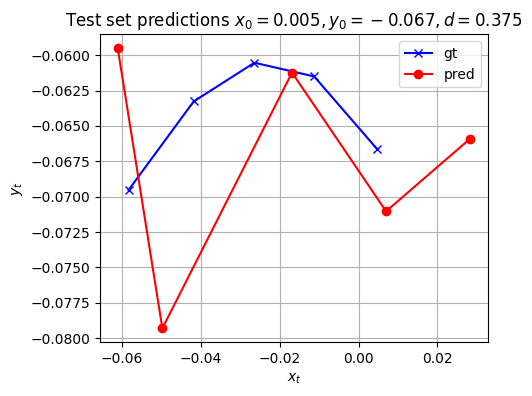


Train set predictions:


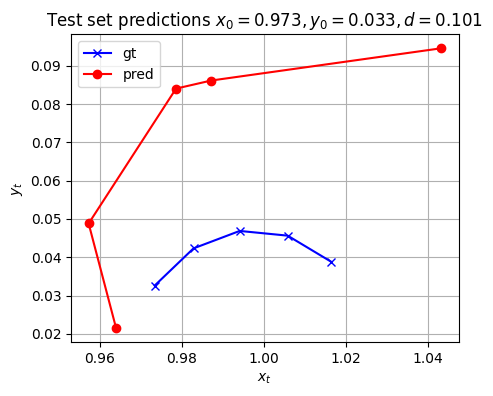

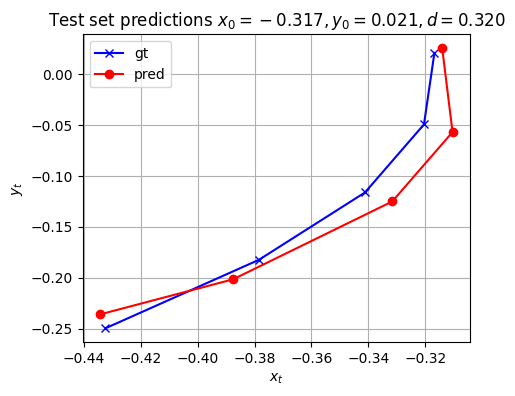


Computing error metrics on test set:
Overall R2-Score (test dataset): 0.9260042905807495

Computing error metrics on train set:
Overall R2-Score (train dataset): 0.9989007711410522


In [12]:
#1. Duffing Oscillator
class LBFGS(torch.optim.LBFGS):
    def __init__(self, params, lr=1, history_size=10, tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32):
        super().__init__(params, lr=lr, history_size=history_size, tolerance_grad=tolerance_grad, 
                         tolerance_change=tolerance_change)
        self.tolerance_ys = tolerance_ys

def compute_jacobian(model, x):
    def ret_sum(x):
        return model(x)
    jacb = autograd.functional.jacobian(ret_sum, x, create_graph=True)
    jacb = jacb[:, :, :, 0]
    jacb = jacb.sum(dim=-1).unsqueeze(-1) 
    return jacb

def compute_ode(y_pred, x):
    def ode(init_cond, d):
        return init_cond[:, 1], init_cond[:, 0] - init_cond[:, 0]**3 - d*init_cond[:, 1]
    grad = ode(y_pred, x[:, 3])
    grad = torch.tensor([[dxdt, dydt] for dxdt, dydt in zip(grad[0], grad[1])], device=device).unsqueeze(-1) 
    return grad

def compute_forward_integrals(dataset, duration, t_eval):
    def system_cont(t, x, d):
        dxdt = [x[1], x[0] - x[0]**3 - d*x[1]]
        return dxdt 
    sol_set = []
    for init_cond in dataset.detach().cpu().numpy():
        t, x0, y0, d = init_cond[0], init_cond[1], init_cond[2], init_cond[3]
        sol = sc.integrate.solve_ivp(system_cont, [0, duration], (x0, y0), args=(d,), t_eval=t_eval)
        sol_set.extend(np.array(sol.y.T))
    sol_set = torch.tensor(np.array(sol_set), dtype=torch.float32, device=device)
    return sol_set

# Loss Function
def ode_residuals(model, coords, steps, duration, t_eval, alpha=1.0, beta=1.0, gamma=1.0):
    coords = coords.clone().detach().requires_grad_(True)
    y_pred = model(coords) 
    y_gt = compute_forward_integrals(coords[::steps], duration, t_eval.cpu().numpy())
    kan_autograd = compute_jacobian(model, coords)
    kan_ode_grad = compute_ode(y_pred, coords)
    init_kan_grad = y_pred[::steps]
    init_ode_grad = coords[::steps][:, 1:3]
    dyn_loss = torch.mean((kan_autograd - kan_ode_grad)**2)
    integral_loss = torch.mean((y_pred - y_gt)**2)
    init_loss = torch.mean((init_kan_grad - init_ode_grad)**2)
    batch_loss = alpha*dyn_loss + beta*integral_loss + beta*init_loss
    return batch_loss

def train(model):
    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, tolerance_grad=1e-32, 
                     tolerance_change=1e-32, tolerance_ys=1e-32)
    iter_ = 5
    for i in range(iter_):
        def closure():
            optimizer.zero_grad()
            loss = ode_residuals(model, dataset, steps, duration, t_eval, alpha=0.2, beta=0.6, gamma=0.2)
            loss.backward()
            return loss
        optimizer.step(closure)
        if i % 1 == 0:
            current_loss = closure().item()
            print(f"Iteration {i}, Loss: {current_loss}")

# Create the dataset for the model
device = "cpu"
s_size = 50
x_sample = np.random.uniform(-1, 1, size=s_size)
y_sample = np.random.uniform(-1, 1, size=s_size)
d_sample = np.random.uniform(0.1, 0.5, size=s_size)
x_sample = torch.tensor(x_sample, dtype=torch.float32, device=device)
y_sample = torch.tensor(y_sample, dtype=torch.float32, device=device)
d_sample = torch.tensor(d_sample, dtype=torch.float32, device=device)
duration = 1
time_interval = 0.2
steps = int(duration / time_interval)
print(f"Steps: {steps}")
t_eval = torch.linspace(0, duration, steps=steps)
dataset = torch.stack([x_sample, y_sample, d_sample], dim=1).to(device)
dataset = dataset.repeat_interleave(steps, dim=0)
t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)
dataset = torch.cat([t_eval_set, dataset], dim=1)
dataset.requires_grad = True
print(f"Dataset shape: {dataset.shape}")
test_size = 5
test_dataset = dataset[(s_size-test_size)*steps:]
dataset = dataset[:(s_size-test_size)*steps]
print(f"Train dataset shape: {dataset.shape}, Test dataset shape: {test_dataset.shape}")

# Base Update and Layernorm must be set to false for verificaton 
kan_duffing = FastKAN(layers_hidden=[4, 15, 2], grid_min=-2., grid_max=2., num_grids=15, use_base_update = False, use_layernorm=False)
print("Starting training...")

train(kan_duffing)
print("\nTest set predictions:")
kan_verification_grapher.graph_ode_results(test_dataset, kan_duffing, steps, t_eval, duration)
print("\nTrain set predictions:")
kan_verification_grapher.graph_ode_results(dataset, kan_duffing, steps, t_eval, duration)

print("\nComputing error metrics on test set:")
sol_map = []
for init_conds in test_dataset[::steps].detach().cpu().numpy():
    sol, _ = kan_verification_grapher.system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map.extend(sol)
pred = kan_duffing(test_dataset).detach().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (test dataset): {res_score}")
print("\nComputing error metrics on train set:")
sol_map = []
for init_conds in dataset[::steps].detach().cpu().numpy():
    sol, _ = kan_verification_grapher.system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map.extend(sol)
pred = kan_duffing(dataset).detach().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (train dataset): {res_score}")

Number of steps: 5
Dataset shape: torch.Size([150, 8])
Train dataset shape: torch.Size([125, 8]), Test dataset shape: torch.Size([25, 8])
Jacobian shape: torch.Size([125, 3, 1])
Training model...
Iteration 0, Loss: 2.107023239135742
Iteration 1, Loss: 1.135477900505066
Iteration 2, Loss: 1.3940861225128174
Iteration 3, Loss: 1.011940360069275
Iteration 4, Loss: 0.6121691465377808

Test set predictions:


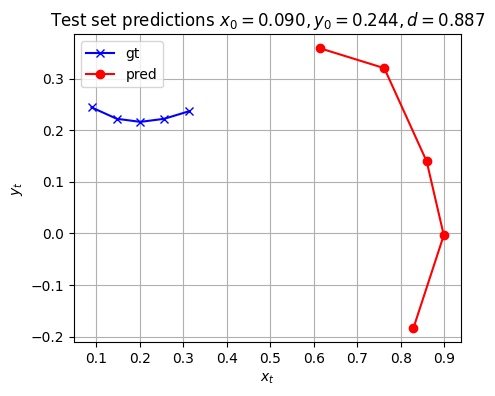

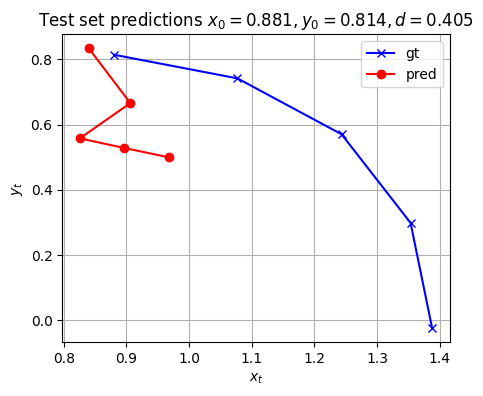


Train set predictions:


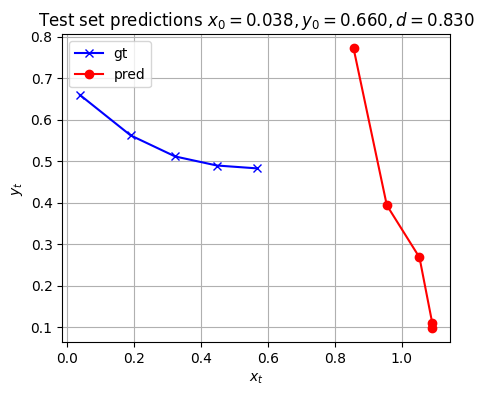

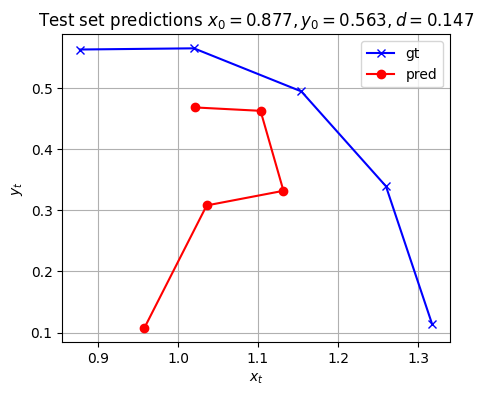


Evaluating test set performance:
Overall R2-Score (test_dataset): -1.6004606485366821

Evaluating train set performance:
Overall R2-Score (train_dataset): -0.31274735927581787


In [25]:
#2 Dampened Pendulum
class LBFGS(optim.LBFGS):
    def __init__(self, params, lr=1, history_size=10, **kwargs):
        super().__init__(params, lr=lr, history_size=history_size, **kwargs)
device = "cpu"
s_size = 30
x_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
y_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
z_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
a_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
b_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
c_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
d_sample = torch.tensor(np.random.uniform(0, 1, size=s_size), dtype=torch.float32, device=device)
duration = 1
time_interval = 0.2
steps = int(duration / time_interval)
print(f"Number of steps: {steps}")
t_eval = torch.linspace(0, duration, steps=int(steps))
dataset = torch.stack([x_sample, y_sample, z_sample, a_sample, b_sample, c_sample, d_sample], dim=1).to(device)
dataset = dataset.repeat_interleave(steps, dim=0)
t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)

dataset = torch.cat([t_eval_set, dataset], dim=1)
dataset.requires_grad = True
print(f"Dataset shape: {dataset.shape}")
test_size = 5
test_dataset = dataset[(s_size-test_size)*steps:]
dataset = dataset[:(s_size-test_size)*steps]
print(f"Train dataset shape: {dataset.shape}, Test dataset shape: {test_dataset.shape}")

def compute_jacobian(model, x):
    def ret_sum(x):
        return model(x)
    jacb = autograd.functional.jacobian(ret_sum, x, create_graph=True)
    jacb = jacb[:, :, :, 0]
    jacb = jacb.sum(dim=-1).unsqueeze(-1)
    return jacb

def compute_ode(y_pred, x):
    def ode(init_cond, a, b, c, d):
        return -a*init_cond[:, 0] + b*init_cond[:, 1] + c*init_cond[:, 2], \
               (d - a)*init_cond[:, 0] - 2*b*init_cond[:, 1], \
               d*init_cond[:, 0] + b*init_cond[:, 1] - c*init_cond[:, 2]

    grad = ode(y_pred, x[:, 4], x[:, 5], x[:, 6], x[:, 7])
    grad = torch.tensor([[dxdt, dydt, dzdt] for dxdt, dydt, dzdt in zip(grad[0], grad[1], grad[2])], 
                        device=device).unsqueeze(-1) 
    return grad

def compute_forward_integrals(dataset, duration, t_eval):
    def system_cont(t, x, a, b, c, d):
        dxdt = [-a*x[0] + b*x[1] + c*x[2], 
                (d - a)*x[0] - 2*b*x[1], 
                d*x[0] + b*x[1] - c*x[2]]
        return dxdt 
    
    sol_set = []
    for init_cond in dataset.detach().cpu().numpy():
        t, x0, y0, z0, a, b, c, d = init_cond[0], init_cond[1], init_cond[2], init_cond[3], \
                                    init_cond[4], init_cond[5], init_cond[6], init_cond[7]
        sol = sc.integrate.solve_ivp(system_cont, [0, duration], (x0, y0, z0), 
                                     args=(a, b, c, d), t_eval=t_eval)
        sol_set.extend(np.array(sol.y.T))
    
    sol_set = torch.tensor(np.array(sol_set), dtype=torch.float32, device=device)
    return sol_set

def ode_residuals(model, coords, steps, duration, t_eval, alpha=1.0, beta=1.0, gamma=1.0):
    coords = coords.clone().detach().requires_grad_(True)
    y_pred = model(coords)
    y_gt = compute_forward_integrals(coords[::steps], duration, t_eval)
    kan_autograd = compute_jacobian(model, coords)
    kan_ode_grad = compute_ode(y_pred, coords) 
    init_kan_grad = y_pred[::steps]
    init_ode_grad = coords[::steps][:, 1:4]

    dyn_loss = torch.mean((kan_autograd - kan_ode_grad)**2)
    integral_loss = torch.mean((y_pred - y_gt)**2)
    init_loss = torch.mean((init_kan_grad - init_ode_grad)**2)
    
    batch_loss = alpha*dyn_loss + beta*integral_loss + gamma*init_loss
    
    return batch_loss

kan_dampened_pendulum = FastKAN(
    layers_hidden=[8, 24, 3],
    grid_min=-2.0,
    grid_max=2.0,
    num_grids=15,
    use_base_update=False,
    use_layernorm=False
)
kan_dampened_pendulum.to(device)

print(f"Jacobian shape: {compute_jacobian(kan_dampened_pendulum, dataset).shape}")

def train(model, iterations=2):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for i in range(iterations):
        optimizer.zero_grad()
        loss = ode_residuals(model, dataset, steps, duration, t_eval)
        loss.backward()
        optimizer.step()
        
        if i % 1 == 0:
            print(f"Iteration {i}, Loss: {loss.item()}")
    
    return model

def system_eq_dis(cond_input, t_eval, time):
    def system_cont(t, x, a, b, c, d):
        dxdt = [-a*x[0] + b*x[1] + c*x[2], 
                (d - a)*x[0] - 2*b*x[1], 
                d*x[0] + b*x[1] - c*x[2]]
        return dxdt
    
    x0, y0, z0, a, b, c, d = cond_input
    sol = sc.integrate.solve_ivp(system_cont, [0, time], (x0, y0, z0), 
                                args=(a, b, c, d), t_eval=t_eval)
    return sol.y.T, sol.t.T

print("Training model...")
kan_dampened_pendulum = train(kan_dampened_pendulum, iterations=5)

print("\nTest set predictions:")
kan_verification_grapher.graph_ode_results(test_dataset, kan_dampened_pendulum, steps, t_eval, duration)
print("\nTrain set predictions:")
kan_verification_grapher.graph_ode_results(dataset, kan_dampened_pendulum, steps, t_eval, duration)

print("\nEvaluating test set performance:")
sol_map = []
for init_conds in test_dataset[::steps].detach().cpu().numpy():
    sol, _ = system_eq_dis(init_conds[1:], t_eval, duration)
    sol_map.extend(sol)

pred = kan_dampened_pendulum(test_dataset).detach().cpu().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (test_dataset): {res_score}")

print("\nEvaluating train set performance:")
sol_map = []
for init_conds in dataset[::steps].detach().cpu().numpy():
    sol, _ = system_eq_dis(init_conds[1:], t_eval, duration)
    sol_map.extend(sol)

pred = kan_dampened_pendulum(dataset).detach().cpu().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (train_dataset): {res_score}")

Using device: cpu
Number of time steps: 5
Dataset shape: torch.Size([150, 7])
Train dataset shape: torch.Size([125, 7]), Test dataset shape: torch.Size([25, 7])
Jacobian shape: torch.Size([125, 2, 1])
Training model...
Starting training...
Epoch 1/5, Loss: 0.00578508
Epoch 2/5, Loss: 0.00088345
Epoch 3/5, Loss: 0.00022701
Epoch 4/5, Loss: 0.00008687
Epoch 5/5, Loss: 0.00004936

Test set predictions:


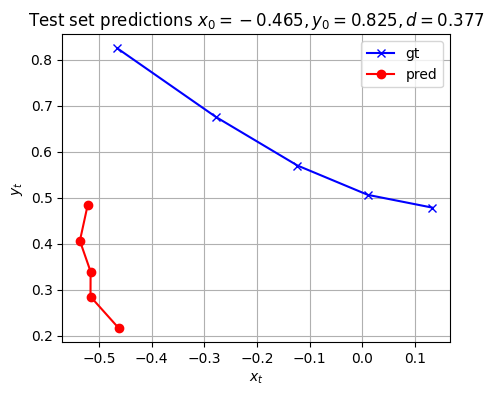

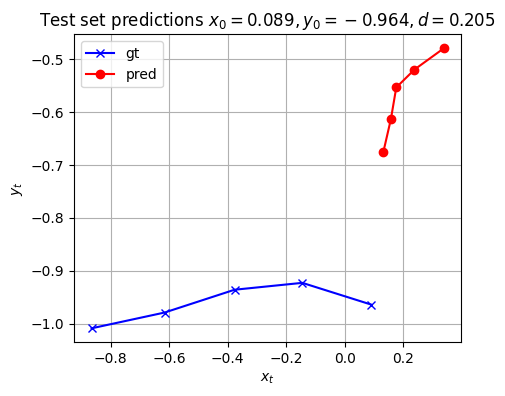


Train set predictions:


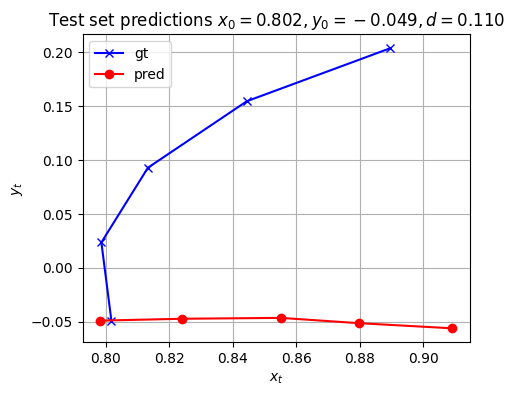

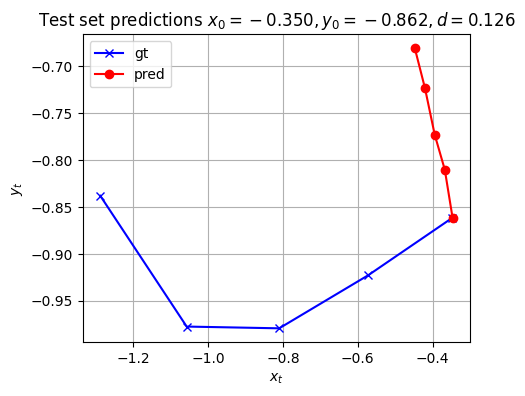


Evaluating test set performance:
Overall R2-Score (test_dataset): 0.857894

Evaluating train set performance:
Overall R2-Score (train_dataset): 0.999931


In [28]:
#3. Lotka Volterra
#3. Lotka Volterra
class LBFGS(optim.LBFGS):
    def __init__(self, params, lr=1, history_size=10, **kwargs):
        super().__init__(params, lr=lr, history_size=history_size, **kwargs)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

s_size = 30
x_sample = torch.tensor(np.random.uniform(-1, 1, size=s_size), dtype=torch.float32, device=device)
y_sample = torch.tensor(np.random.uniform(-1, 1, size=s_size), dtype=torch.float32, device=device)
a_sample = torch.tensor(np.random.uniform(0.1, 0.5, size=s_size), dtype=torch.float32, device=device)
b_sample = torch.tensor(np.random.uniform(0.1, 0.5, size=s_size), dtype=torch.float32, device=device)
c_sample = torch.tensor(np.random.uniform(0.1, 0.5, size=s_size), dtype=torch.float32, device=device)
d_sample = torch.tensor(np.random.uniform(0.1, 0.5, size=s_size), dtype=torch.float32, device=device)

duration = 1
time_interval = 0.2
steps = int(duration / time_interval)
t_eval = torch.linspace(0, duration, steps=int(steps))
print(f"Number of time steps: {steps}")

dataset = torch.stack([x_sample, y_sample, a_sample, b_sample, c_sample, d_sample], dim=1).to(device)
dataset = dataset.repeat_interleave(steps, dim=0)
t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)

dataset = torch.cat([t_eval_set, dataset], dim=1)
dataset.requires_grad = True
print(f"Dataset shape: {dataset.shape}")

test_size = 5
test_dataset = dataset[(s_size-test_size)*steps:]
train_dataset = dataset[:(s_size-test_size)*steps]
print(f"Train dataset shape: {train_dataset.shape}, Test dataset shape: {test_dataset.shape}")

def compute_jacobian(model, x):
    def ret_sum(x):
        return model(x)
    
    jacb = autograd.functional.jacobian(ret_sum, x, create_graph=True)
    jacb = jacb[:, :, :, 0]
    jacb = jacb.sum(dim=-1).unsqueeze(-1)
    return jacb

def compute_ode(y_pred, x):
    def ode(init_cond, a, b, c, d):
        return (
            init_cond[:, 0]*a - init_cond[:, 0]*init_cond[:, 1]*b, 
            -init_cond[:, 1]*c + init_cond[:, 0]*init_cond[:, 1]*d
        )

    grad = ode(y_pred, x[:, 3], x[:, 4], x[:, 5], x[:, 6])
    grad = torch.stack([grad[0], grad[1]], dim=1).unsqueeze(-1)
    return grad

def compute_forward_integrals(dataset, duration, t_eval):
    def system_cont(t, x, a, b, c, d):
        dxdt = [x[0]*a - x[0]*x[1]*b, -x[1]*c + x[0]*x[1]*d]
        return dxdt 
    
    sol_set = []
    for init_cond in dataset.detach().cpu().numpy():
        t, x0, y0, a, b, c, d = init_cond[0], init_cond[1], init_cond[2], init_cond[3], init_cond[4], init_cond[5], init_cond[6]
        sol = sc.integrate.solve_ivp(system_cont, [0, duration], (x0, y0), args=(a, b, c, d), t_eval=t_eval)
        sol_set.extend(np.array(sol.y.T))
    
    sol_set = torch.tensor(np.array(sol_set), dtype=torch.float32, device=dataset.device)
    return sol_set

def ode_residuals(model, coords, steps, duration, t_eval, alpha=1.0, beta=1.0, gamma=1.0):
    coords = coords.clone().detach().requires_grad_(True)

    y_pred = model(coords)
    y_gt = compute_forward_integrals(coords[::steps], duration, t_eval)

    kan_autograd = compute_jacobian(model, coords)
    kan_ode_grad = compute_ode(y_pred, coords)

    init_kan_grad = y_pred[::steps]
    init_ode_grad = torch.stack([coords[::steps][:, 1], coords[::steps][:, 2]], dim=1)

    dyn_loss = torch.mean((kan_autograd - kan_ode_grad)**2)
    integral_loss = torch.mean((y_pred - y_gt)**2)
    init_loss = torch.mean((init_kan_grad - init_ode_grad)**2)
    
    batch_loss = alpha*dyn_loss + beta*integral_loss + gamma*init_loss

    return batch_loss

def system_eq_dis(cond_input, t_eval, duration):
    def system_cont(t, x, a, b, c, d):
        dxdt = [x[0]*a - x[0]*x[1]*b, -x[1]*c + x[0]*x[1]*d]
        return dxdt
        
    x0, y0, a, b, c, d = cond_input
    sol = sc.integrate.solve_ivp(system_cont, [0, duration], (x0, y0), args=(a, b, c, d), t_eval=t_eval)
    return sol.y.T, sol.t.T

kan_lotka_volterra = FastKAN(
    layers_hidden=[7, 24, 2],
    grid_min=-2.0,
    grid_max=2.0,
    num_grids=15,
    use_base_update=False,
    use_layernorm=False
)
kan_lotka_volterra.to(device)

print(f"Jacobian shape: {compute_jacobian(kan_lotka_volterra, train_dataset).shape}")

def train(model, iterations=5):
    optimizer = optim.LBFGS(model.parameters(), 
                           lr=1, 
                           max_iter=20,
                           max_eval=25, 
                           tolerance_grad=1e-7,
                           tolerance_change=1e-9,
                           history_size=10)
    
    print("Starting training...")
    for epoch in range(iterations):
        def closure():
            optimizer.zero_grad()
            loss = ode_residuals(model, train_dataset, steps, duration, t_eval.numpy(), 
                               alpha=0.2, beta=0.6, gamma=0.2)
            loss.backward()
            return loss
        
        optimizer.step(closure)
        current_loss = closure().item()
        print(f"Epoch {epoch+1}/{iterations}, Loss: {current_loss:.8f}")
    
    return model

print("Training model...")
kan_lotka_volterra = train(kan_lotka_volterra, iterations=5)

print("\nTest set predictions:")
kan_verification_grapher.graph_ode_results(test_dataset, kan_lotka_volterra, steps, t_eval, duration)
print("\nTrain set predictions:")
kan_verification_grapher.graph_ode_results(train_dataset, kan_lotka_volterra, steps, t_eval, duration)

print("\nEvaluating test set performance:")
sol_map_test = []
for init_conds in test_dataset[::steps].detach().cpu().numpy():
    sol, _ = system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map_test.extend(sol)

with torch.no_grad():
    pred_test = kan_lotka_volterra(test_dataset).detach().cpu().numpy()

res_score_test = r2_score(sol_map_test, pred_test)
print(f"Overall R2-Score (test_dataset): {res_score_test:.6f}")

print("\nEvaluating train set performance:")
sol_map_train = []
for init_conds in train_dataset[::steps].detach().cpu().numpy():
    sol, _ = system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map_train.extend(sol)

with torch.no_grad():
    pred_train = kan_lotka_volterra(train_dataset).detach().cpu().numpy()

res_score_train = r2_score(sol_map_train, pred_train)
print(f"Overall R2-Score (train_dataset): {res_score_train:.6f}")

In [3]:
def train_mnist():
    ssl._create_default_https_context = ssl._create_unverified_context
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    trainset = torchvision.datasets.MNIST(
        root="./data_mnist", train=True, download=True, transform=transform
    )
    valset = torchvision.datasets.MNIST(
        root="./data_mnist", train=False, download=True, transform=transform
    )
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    valloader = DataLoader(valset, batch_size=64, shuffle=False)

    model = FastKAN([28 * 28, 16, 10], use_base_update=False, use_layernorm=False)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

    criterion = nn.CrossEntropyLoss()
    for epoch in range(10):
        model.train()
        with tqdm(trainloader) as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.view(-1, 28 * 28).to(device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                loss.backward()
                optimizer.step()
                accuracy = (output.argmax(dim=1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for images, labels in valloader:
                images = images.view(-1, 28 * 28).to(device)
                output = model(images)
                val_loss += criterion(output, labels.to(device)).item()
                val_accuracy += (
                    (output.argmax(dim=1) == labels.to(device)).float().mean().item()
                )
        val_loss /= len(valloader)
        val_accuracy /= len(valloader)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}"
        )
    return model

kan_mnist = train_mnist()

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 260kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.02MB/s]
100%|██████████| 938/938 [00:04<00:00, 194.34it/s, accuracy=0.688, loss=0.92, lr=0.001] 


Epoch 1, Val Loss: 0.8803610828272097, Val Accuracy: 0.7849323248407644


100%|██████████| 938/938 [00:04<00:00, 190.92it/s, accuracy=0.844, loss=0.694, lr=0.0008]


Epoch 2, Val Loss: 0.5341740112965274, Val Accuracy: 0.8560907643312102


100%|██████████| 938/938 [00:04<00:00, 188.91it/s, accuracy=0.969, loss=0.21, lr=0.00064] 


...

Epoch 8, Val Loss: 0.2930102242500919, Val Accuracy: 0.9116242038216561


100%|██████████| 938/938 [00:04<00:00, 211.60it/s, accuracy=0.969, loss=0.157, lr=0.000168] 


Epoch 9, Val Loss: 0.28316001703215254, Val Accuracy: 0.9152070063694268


100%|██████████| 938/938 [00:04<00:00, 218.63it/s, accuracy=0.938, loss=0.344, lr=0.000134] 


Epoch 10, Val Loss: 0.2745002914267551, Val Accuracy: 0.9184912420382165


In [9]:
def train_cifar10():
    ssl._create_default_https_context = ssl._create_unverified_context
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    trainset = torchvision.datasets.CIFAR10(
        root="./data_cifar10", train=True, download=True, transform=transform
    )
    valset = torchvision.datasets.CIFAR10(
        root="./data_cifar10", train=False, download=True, transform=transform
    )
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    valloader = DataLoader(valset, batch_size=64, shuffle=False)

    model = FastKAN([3072, 16, 10])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

    criterion = nn.CrossEntropyLoss()
    for epoch in range(10):
        model.train()
        with tqdm(trainloader) as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.view(-1, 3072).to(device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                loss.backward()
                optimizer.step()
                accuracy = (output.argmax(dim=1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for images, labels in valloader:
                images = images.view(-1, 3072).to(device)
                output = model(images)
                val_loss += criterion(output, labels.to(device)).item()
                val_accuracy += (
                    (output.argmax(dim=1) == labels.to(device)).float().mean().item()
                )
        val_loss /= len(valloader)
        val_accuracy /= len(valloader)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}"
        )
    return model

kan_cifar10 = train_cifar10()

100%|██████████| 782/782 [00:08<00:00, 89.28it/s, accuracy=0.312, loss=1.98, lr=0.001]


Epoch 1, Val Loss: 1.6180718711986664, Val Accuracy: 0.43451433121019106


100%|██████████| 782/782 [00:09<00:00, 84.02it/s, accuracy=0.562, loss=1.45, lr=0.0008]


Epoch 2, Val Loss: 1.5316637594988392, Val Accuracy: 0.46476910828025475


100%|██████████| 782/782 [00:09<00:00, 81.05it/s, accuracy=0.562, loss=1.36, lr=0.00064] 


...

Epoch 8, Val Loss: 1.5697106677255812, Val Accuracy: 0.4666600318471338


100%|██████████| 782/782 [00:10<00:00, 77.87it/s, accuracy=0.625, loss=1.28, lr=0.000168] 


Epoch 9, Val Loss: 1.5865379549135827, Val Accuracy: 0.46078821656050956


100%|██████████| 782/782 [00:08<00:00, 89.06it/s, accuracy=0.625, loss=1.03, lr=0.000134] 


Epoch 10, Val Loss: 1.5987343575544417, Val Accuracy: 0.46208200636942676


# Fitting Linear Segments (Vanilla)

![image.png](images/DP_bspline.png)

Fitting Layer 0 (4 -> 15)
Fitting Layer 1 (15 -> 2)
Generated data for 90 connections.


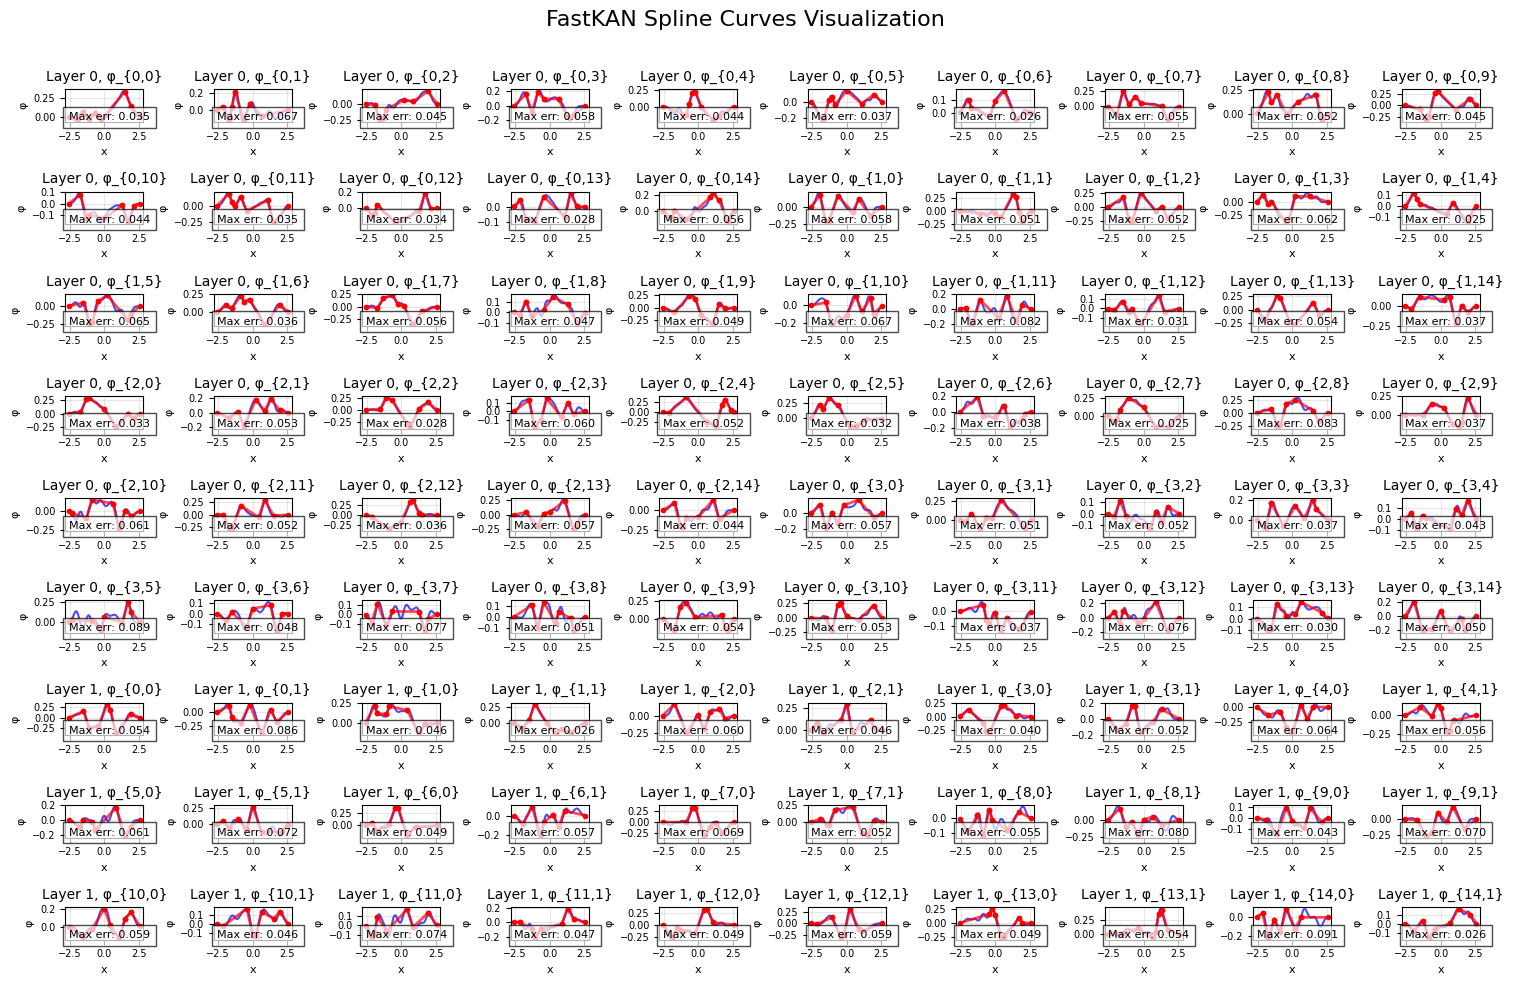

In [13]:
def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_bspline_segments_given_max_segments(layer, input_index, output_index, max_segments, min_x, max_x):
    """
    Used in both the vanilla fitting method and DP method.
    Given a single B-Spline in the network and a budget of segments,
    use DP to fit them optimally (minimizing the max error).
    """
    # Sample points from the spline (within defined x range)
    n_samples = 25
    x_points = np.linspace(min_x, max_x, n_samples)
    x_tensor, y_tensor = layer.plot_curve(input_index, output_index, num_pts=n_samples)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_points = x_np[mask]
    y_points = y_np[mask]
    n = len(x_points)
    
    # Precompute errors for all possible segments
    errors = np.full((n, n), np.inf)
    for start_idx in range(n-1):
        max_len = min(n - start_idx, int(np.round((max_x - min_x) / ((max_x - min_x) / n))))
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, start_idx + max_len):
            if end_idx >= n:
                break
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            if abs(x_end - x_start) <= 1e-10:
                continue
            slope = (y_end - y_start) / (x_end - x_start)
            intercept = y_start - slope * x_start
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # Dynamic programming to find optimal segmentation
    dp = np.full((max_segments, n), np.inf)
    back = np.zeros((max_segments, n), dtype=int)
    for j in range(1, n):  # Base Case: one segment from start to j
        dp[0, j] = errors[0, j] 
    # TODO: add in recurrence relation
    for i in range(1, max_segments):
        for j in range(i+1, n):
            for k in range(i, j):
                if dp[i-1, k] == np.inf:
                    continue
                if errors[k, j] == np.inf:
                    continue
                curr_error = max(dp[i-1, k], errors[k, j])
                if curr_error < dp[i, j]:
                    dp[i, j] = curr_error
                    back[i, j] = k
    
    # Reconstruct the segments
    segments = []
    curr_seg = n - 1
    if dp[max_segments-1, curr_seg] == np.inf:
        return [], np.inf
    for i in range(max_segments-1, -1, -1):
        if i > 0:
            prev_seg = back[i, curr_seg]
        else:
            prev_seg = 0
        x1, y1 = x_points[prev_seg], y_points[prev_seg]
        x2, y2 = x_points[curr_seg], y_points[curr_seg]
        slope, intercept = fit_line_through_points(x1, y1, x2, y2)
        segments.insert(0, (x1, x2, slope, intercept))
        curr_seg = prev_seg
        if curr_seg <= 0:
            break
        
    return segments, dp[max_segments-1, n-1]

def fit_kan_vanilla(kan_model, segments_per_curve, min_x, max_x):
    """
    Our baseline fitting method for the KAN model.
    We assign the same number of segments to each curve for approximation.
    Then, use Gurobi to solve for output bounds and track time to get a target to beat.
    """
    all_segments = []
    for layer_idx, layer in enumerate(kan_model.layers):
        layer.cpu()
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Fitting Layer {layer_idx} ({input_dim} -> {output_dim})")
        for input_index in range(input_dim):
            for output_index in range(output_dim):
                segments, max_error = find_bspline_segments_given_max_segments(layer, input_index, output_index, segments_per_curve, min_x, max_x)
                all_segments.append({
                    'layer_idx': layer_idx,
                    'input_idx': input_index,
                    'output_idx': output_index,
                    'segments': segments,
                    'max_error': max_error
                })
    print(f"Generated data for {len(all_segments)} connections.")
    return all_segments


all_segments = fit_kan_vanilla(
    kan_duffing,
    min_x=-5.0,
    max_x=5.0,
    segments_per_curve=8
)

fig = kan_verification_grapher.plot_kan(
    kan_duffing,
    all_segments,
    figsize=(15, 10),
    min_x=-5.0,
    max_x=5.0,
    num_pts=100,
)
plt.show()

# Fitting Linear Segments (Lipschitz DP Method)

### Generate DP Tables for Every B-Spline

![image.png](images/DP_kan.png)

In [14]:
def calculate_bspline_lipschitz_constant(layer: 'FastKANLayer', input_idx: int, output_idx: int, num_pts: int = 1000, min_x: float = None, max_x: float = None) -> float:
    if min_x is None:
        min_x = layer.rbf.grid_min
    if max_x is None:
        max_x = layer.rbf.grid_max
    x_tensor, y_tensor = layer.plot_curve(input_idx, output_idx, num_pts=num_pts)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_np = x_np[mask]
    y_np = y_np[mask]

    dx = np.diff(x_np)
    dy = np.diff(y_np)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def compute_dp_tables_lipschitz(kan_model, min_x=-5.0, max_x=5.0, max_segments=15):
    """
    Compute the error tables, segments tables, and Lipschitz constants for all B-splines in the KAN model.
    This is used for the DP method later.
    """
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}
    
    # Iterate through all layers
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Analyzing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        # Iterate through all B-splines in this layer
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                layer = kan_model.layers[layer_idx]
                error_table = {}
                segments_table = {}
                for num_segments in range(1, max_segments + 1):
                    segments, error = find_bspline_segments_given_max_segments(layer, input_idx, output_idx, num_segments, min_x, max_x)
                    error_table[num_segments] = error
                    segments_table[num_segments] = segments
                lipschitz_constant = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx, output_idx=output_idx)
                error_tables[spline_key] = error_table
                segments_tables[spline_key] = segments_table
                lipschitz_constants[spline_key] = lipschitz_constant
    
    return error_tables, segments_tables, lipschitz_constants

### Weight DP Table Using Lipschitz Constants

![image.png](images/lipschitz.jpg)

Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs
Weighing Layer 0: 4 inputs -> 15 outputs
Weighing Layer 1: 15 inputs -> 2 outputs
  Achieved error: 0.09983500838279724
  Total segments allocated: 434

Dynamic Programming Table (Error values):
--------------------------------------------------------------------------------
Spline \ Segments |     0 |    20 |    40 |    60 |    80 |   100 |   120 |   140 |   160 |   180 |   200 |   220 |   240 |   260 |   280 |   300 |   320 |   340 |   360 |   380 |   400 |   420
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  0 | 0.000 | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf  
  1 | inf   | 0.004 | inf   | inf   | inf   | inf   | inf   | inf   | in

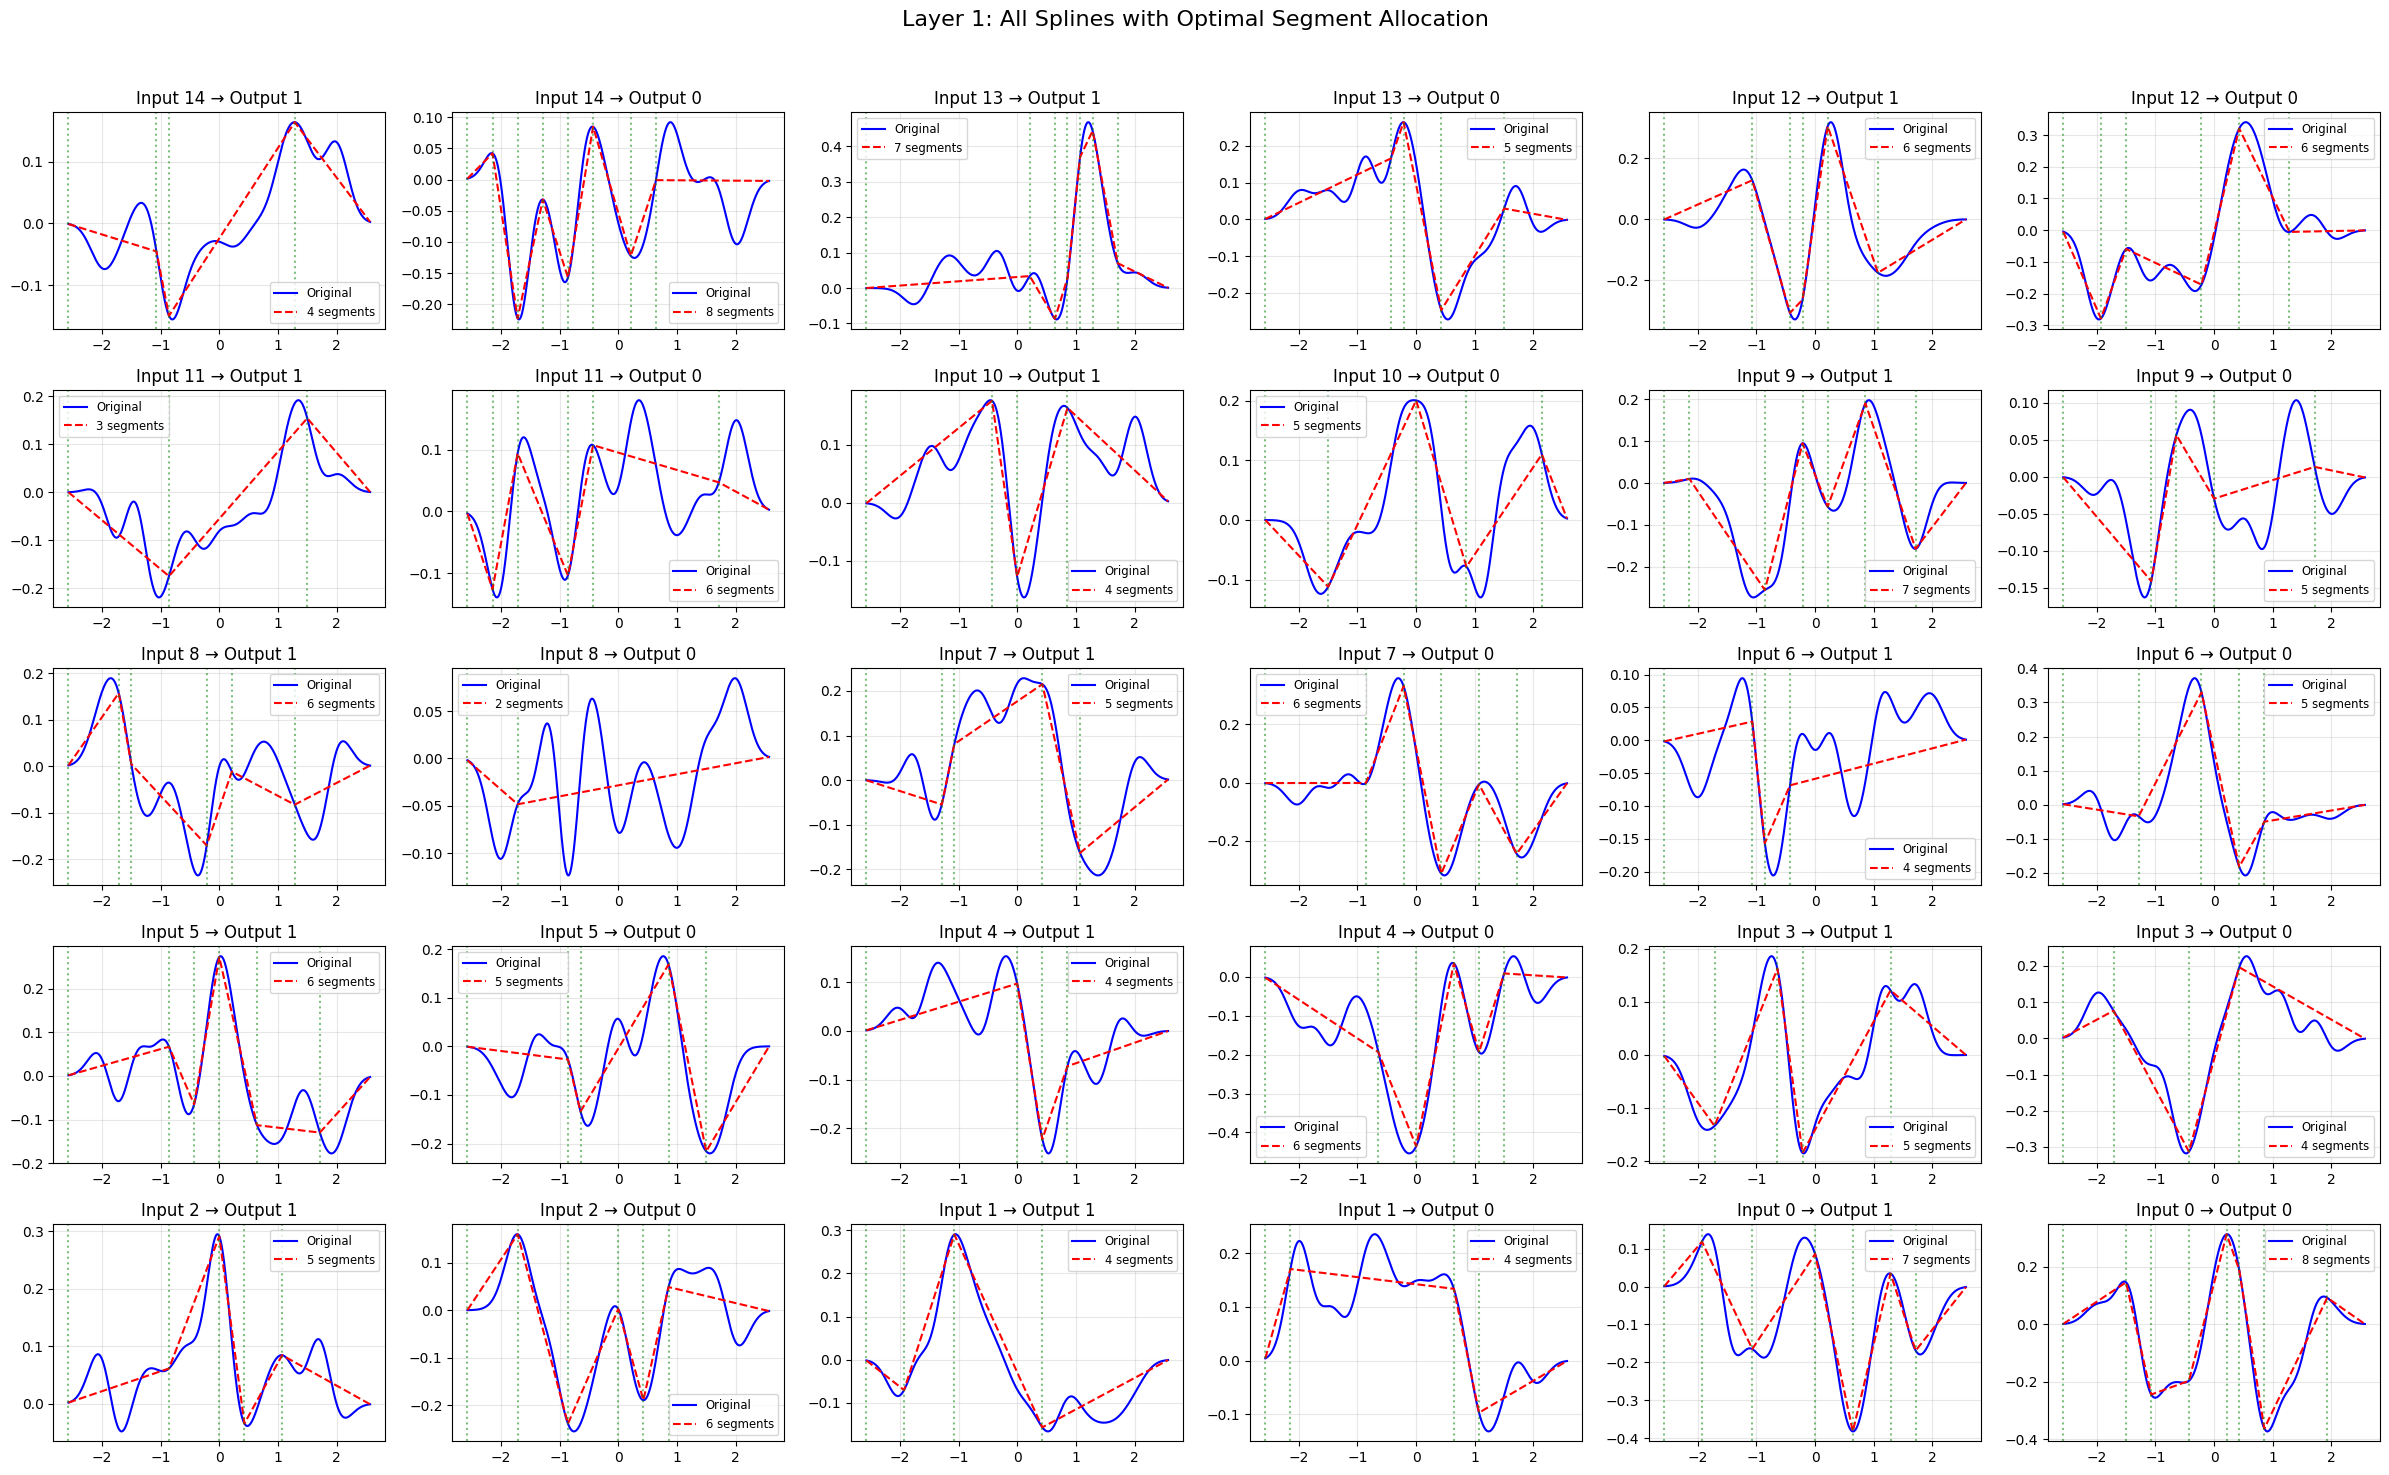

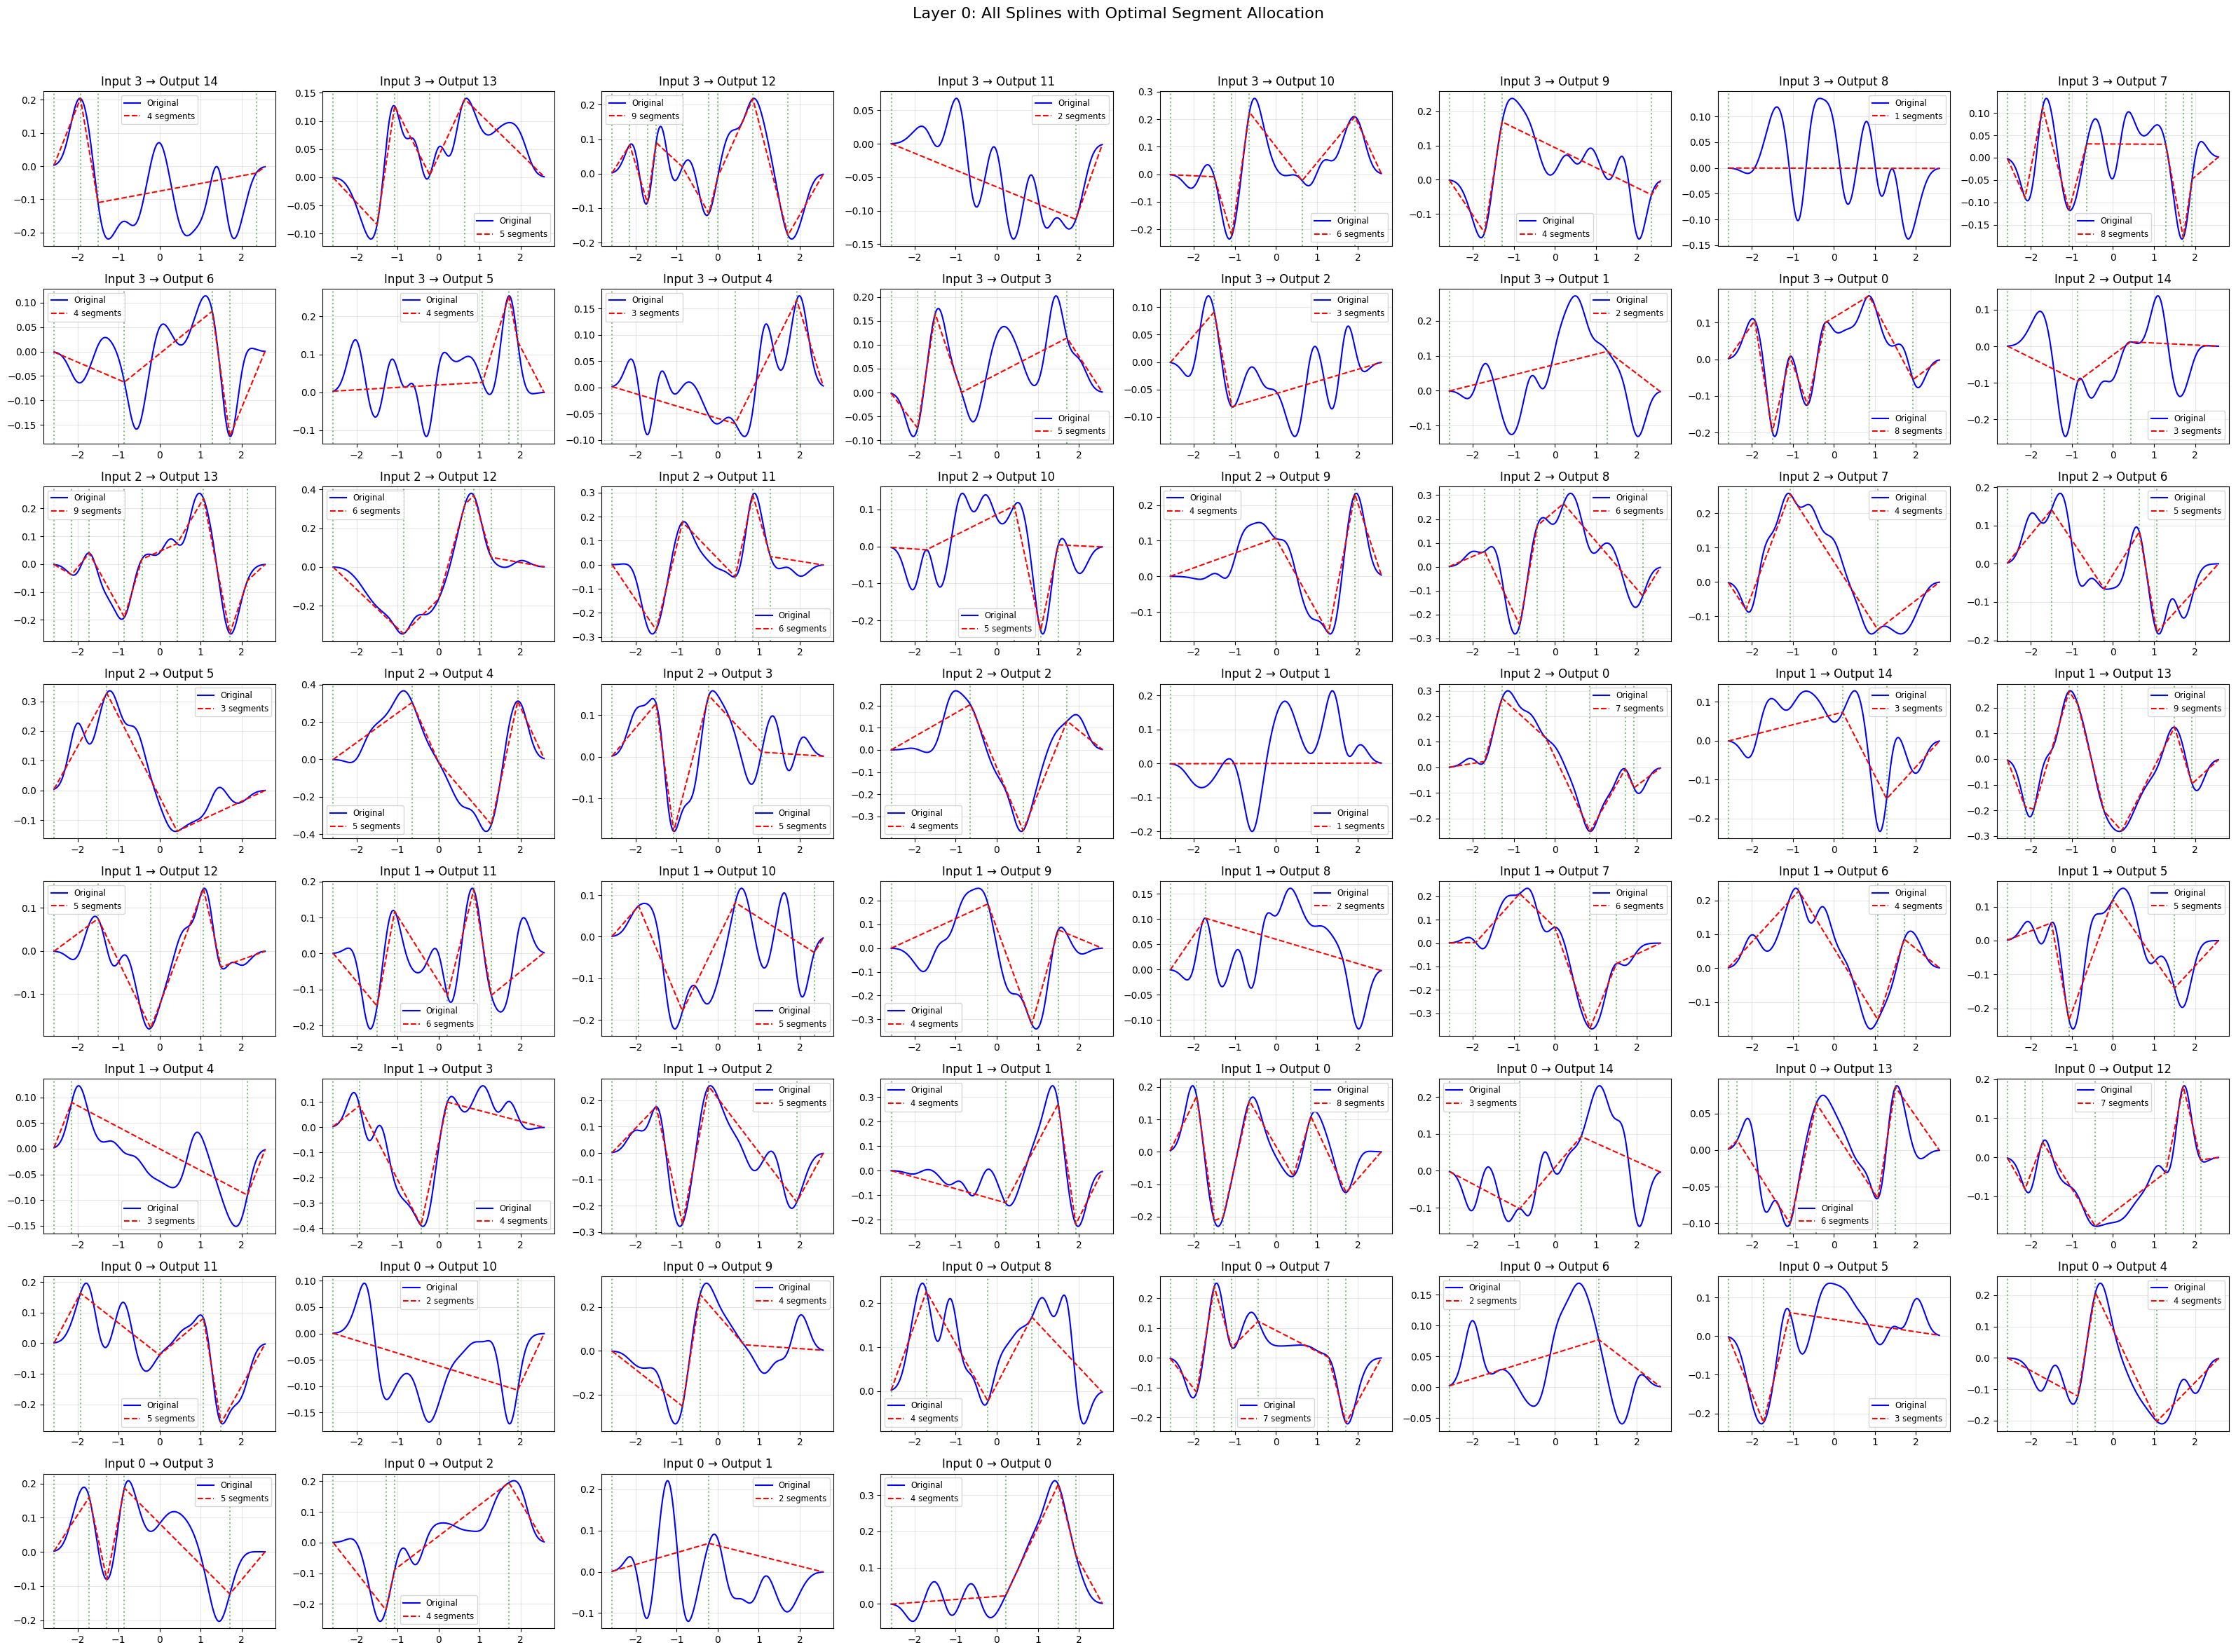

In [15]:
def get_all_downstream_splines(kan_model, layer_idx, output_idx, visited=None):
    """
    Find all downstream splines in the KAN model starting from a given spline (at position layer_idx, output_idx).
    This is used to compute the Lipschitz constant for a certain spline.
    """
    if visited is None:
        visited = set()
    # Base Case: last layer has no downstream splines
    if layer_idx >= len(kan_model.layers) - 1:
        return set()
    # The output of current spline becomes an input in the next layer
    next_input_idx = output_idx
    next_layer_idx = layer_idx + 1
    next_layer = kan_model.layers[next_layer_idx]
    downstream_splines = set()
    for next_output_idx in range(next_layer.output_dim):
        next_spline = (next_layer_idx, next_input_idx, next_output_idx)
        if next_spline not in visited:
            visited.add(next_spline)
            downstream_splines.add(next_spline)
            further_downstream = get_all_downstream_splines(kan_model, next_layer_idx, next_output_idx, visited)
            downstream_splines.update(further_downstream)
    return downstream_splines

def weight_dp_tables_lipschitz(kan_model, min_x=-5.0, max_x=5.0, max_segments=15):
    """
    Weight the error tables for every B-Spline by the product of Lipschitz constants of all downstream splines.
    (ie. weight the error tables by their overall effect on the network output bound)
    """
    error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments)
    weighted_error_tables = {}
    # Iterate through all splines in the network
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Weighing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                downstream_splines = get_all_downstream_splines(kan_model, layer_idx, output_idx)
                # Weight the error table by computing the product of Lipschitz constants of all downstream splines
                lipschitz_product = 1.0
                for downstream_spline in downstream_splines:
                    if downstream_spline in lipschitz_constants:
                        lipschitz_product *= lipschitz_constants[downstream_spline]
                weighted_table = {}
                for num_segments, error in error_tables[spline_key].items():
                    weighted_table[num_segments] = error * lipschitz_product
                weighted_error_tables[spline_key] = weighted_table
    return weighted_error_tables, segments_tables, lipschitz_constants

def fit_kan_optimally_lipschitz(weighted_error_tables, segments_tables, max_error, max_segments=50):
    """
    Use DP to find the optimal allocation of segments to splines in the KAN model.
    (Use the weighted error tables computed above).
    """
    used_backup_allocation = False
    all_splines = list(weighted_error_tables.keys())
    num_splines = len(all_splines)
    max_total_segments = num_splines * max_segments
    
    # Initialization: dp[i][j] = minimum error achievable when allocating j total segments to the first i splines
    dp = np.full((num_splines + 1, max_total_segments + 1), float('inf'))
    dp[0, 0] = 0  # Base case: 0 error when allocating 0 segments to 0 splines
    backtrack = np.zeros((num_splines + 1, max_total_segments + 1), dtype=int)
    for i in range(1, num_splines + 1):
        spline_key = all_splines[i-1]
        for j in range(max_total_segments + 1):
            # Try different allocations for the current spline (updating allocation if we find a better error)
            for segs in range(min(j + 1, max_segments + 1)):
                if segs not in weighted_error_tables[spline_key]:
                    continue
                spline_error = weighted_error_tables[spline_key][segs]
                prev_error = dp[i-1, j-segs]
                if prev_error != float('inf') and max(prev_error, spline_error) < dp[i, j]:
                    dp[i, j] = max(prev_error, spline_error)
                    backtrack[i, j] = segs
    
    # Backtrack: Find the min total segments to achieve error <= max_error
    optimal_total_segments = None
    achieved_error = float('inf')
    for j in range(max_total_segments + 1):
        if dp[num_splines, j] <= max_error:
            optimal_total_segments = j
            achieved_error = dp[num_splines, j]
            break
    if optimal_total_segments is None:
        min_error_idx = np.argmin(dp[num_splines, :])
        optimal_total_segments = min_error_idx
        achieved_error = dp[num_splines, min_error_idx]
        print(f"Could not find allocation satisfying the max error constraint ({max_error}).")
        print(f"Returning best allocation with error: {achieved_error}")
        used_backup_allocation = True
    optimal_allocation = {}
    actual_segments = {}
    remaining_segments = optimal_total_segments
    for i in range(num_splines, 0, -1):
        spline_key = all_splines[i-1]
        # Get the segment allocation for this spline and store the coordinates of its linear segments
        segs_for_spline = int(backtrack[i, remaining_segments])
        optimal_allocation[spline_key] = segs_for_spline
        actual_segments[spline_key] = segments_tables[spline_key].get(segs_for_spline, [])
        remaining_segments -= segs_for_spline
    total_segments = sum(optimal_allocation.values())
    print(f"  Achieved error: {achieved_error}")
    print(f"  Total segments allocated: {total_segments}")

    return optimal_allocation, actual_segments, total_segments, achieved_error, dp, used_backup_allocation

weighted_error_tables, segments_tables, lipschitz_constants = weight_dp_tables_lipschitz(
    kan_duffing, min_x=-5.0, max_x=5.0, max_segments=30
)
optimal_allocation, actual_segments, total_segments, achieved_error, dp_table, _ = fit_kan_optimally_lipschitz(
    weighted_error_tables, 
    segments_tables,
    max_error=0.1
)
kan_verification_grapher.print_dp_table(dp_table, len(optimal_allocation), total_segments)
figures = kan_verification_grapher.visualize_all_splines(kan_duffing, optimal_allocation, actual_segments)

# MILP Verification

![image.png](images/MILP.jpg)

### Defining MILP Solver

In [16]:
class SplineApproximation:
    """
    Class to represent a spline approximation for a single connection in the KAN model.
    """
    def __init__(self, segments: List[Tuple[float, float, float, float]], max_error: float):
        self.segments = sorted(segments, key=lambda s: s[0]) if segments else []
        self.original_max_error = max_error
        self.max_error_mip = max_error if np.isfinite(max_error) else 1e7 # For MIP solver stability

    def is_valid(self):
        return bool(self.segments) and np.isfinite(self.original_max_error)


def prep_segments_data(kan_segments_data: List[dict], input_dim: int, hidden_dim: int, output_dim: int):
    """
    Seperate the segments data by layer to make verification easier.
    """
    layer0_approximations = [[None for _ in range(hidden_dim)] for _ in range(input_dim)]
    layer1_approximations = [[None for _ in range(output_dim)] for _ in range(hidden_dim)]
    processed_indices_l0 = set()
    processed_indices_l1 = set()
    segments_layer0 = [s for s in kan_segments_data if s['layer_idx'] == 0]
    segments_layer1 = [s for s in kan_segments_data if s['layer_idx'] == 1]

    for seg_data in segments_layer0:
        i = seg_data['input_idx']
        h = seg_data['output_idx']
        approx = SplineApproximation(seg_data['segments'], seg_data['max_error'])
        layer0_approximations[i][h] = approx
        processed_indices_l0.add((i, h))

    for seg_data in segments_layer1:
        h = seg_data['input_idx']
        o = seg_data['output_idx']
        approx = SplineApproximation(seg_data['segments'], seg_data['max_error'])
        layer1_approximations[h][o] = approx
        processed_indices_l1.add((h, o))

    return layer0_approximations, layer1_approximations

def MIP_interval_analysis(
    layer0_approximations: List[List[Optional[SplineApproximation]]],
    layer1_approximations: List[List[Optional[SplineApproximation]]],
    x_min_vec: Union[List[float], np.ndarray],
    x_max_vec: Union[List[float], np.ndarray],
    M: float = 1e4,
):
    """
    Set up the MIP problem for the KAN model using the provided layer approximations and input bounds.
    Returns the results of the optimization for each output dimension.
    """
    if (not layer0_approximations or not layer0_approximations[0]) or (not layer1_approximations or not layer1_approximations[0]):
        print("Error: layer_approximations is empty or invalid.")
        return []
    input_dim = len(layer0_approximations)
    hidden_dim = len(layer0_approximations[0])
    output_dim = len(layer1_approximations[0])
    if len(x_min_vec) != input_dim or len(x_max_vec) != input_dim:
        raise ValueError(f"Input bounds vector length mismatch. Expected {input_dim}, got min:{len(x_min_vec)}, max:{len(x_max_vec)}")
    print(f"Setting up MIP for KAN [{input_dim}, {hidden_dim}, {output_dim}]...")
    print(f"Input bounds: {list(zip(x_min_vec, x_max_vec))}")


    # Define Variables
    x_vars = [LpVariable(f"x_{i}", lowBound=x_min_vec[i], upBound=x_max_vec[i]) for i in range(input_dim)]
    layer0_spline_outputs = [[LpVariable(f"l0_spline_{i}_{h}") for h in range(hidden_dim)] for i in range(input_dim)]
    hidden_activations = [LpVariable(f"hidden_act_{h}") for h in range(hidden_dim)]
    layer1_spline_outputs = [[LpVariable(f"l1_spline_{h}_{o}") for o in range(output_dim)] for h in range(hidden_dim)]
    output_vars = [LpVariable(f"output_{o}") for o in range(output_dim)] # Bounds are the goal


    # Binary indicators for segment selection (layer 0 defined first, then layer 1)
    layer0_indicators = []
    for i in range(input_dim):
        indicators_i = []
        for h in range(hidden_dim):
            approx = layer0_approximations[i][h]
            if approx and approx.segments:
                indicators_i.append([LpVariable(f"l0_ind_{i}_{h}_seg_{j}", cat=LpBinary) for j in range(len(approx.segments))])
            else:
                indicators_i.append([]) # No indicators if no segments
        layer0_indicators.append(indicators_i)
    layer1_indicators = []
    for h in range(hidden_dim):
        indicators_h = []
        for o in range(output_dim):
            approx = layer1_approximations[h][o]
            if approx and approx.segments:
                indicators_h.append([LpVariable(f"l1_ind_{h}_{o}_seg_{j}", cat=LpBinary) for j in range(len(approx.segments))])
            else:
                indicators_h.append([])
        layer1_indicators.append(indicators_h)


    # Define Constraints
    base_constraints = []
    # Layer 0 (Input -> Hidden)
    for i in range(input_dim):
        for h in range(hidden_dim):
            approx = layer0_approximations[i][h]
            x_input = x_vars[i] # Input for this spline connection
            spline_output_var = layer0_spline_outputs[i][h]
            indicators = layer0_indicators[i][h]
            if indicators: # 1. One segment must be active
                base_constraints.append(lpSum(indicators) == 1)
            for j, (start_x, end_x, slope, intercept) in enumerate(approx.segments): # 2. Constrain x bounds and output value
                indicator = indicators[j]
                y_approx = slope * x_input + intercept
                base_constraints.append(x_input >= start_x - M * (1 - indicator))
                base_constraints.append(x_input <= end_x + M * (1 - indicator))
                error = approx.max_error_mip
                base_constraints.append(spline_output_var <= y_approx + error + M * (1 - indicator))
                base_constraints.append(spline_output_var >= y_approx - error - M * (1 - indicator))
    # Hidden Layer
    for h in range(hidden_dim):
        incoming_splines = [layer0_spline_outputs[i][h] for i in range(input_dim)]
        base_constraints.append(hidden_activations[h] == lpSum(incoming_splines)) # Value of activation h in hidden layer = sum over incoming splines
    # Layer 1 (Hidden -> Output)
    for h in range(hidden_dim):
        for o in range(output_dim):
            approx = layer1_approximations[h][o]
            hidden_input = hidden_activations[h] # Input for this spline connection
            spline_output_var = layer1_spline_outputs[h][o]
            indicators = layer1_indicators[h][o]
            if indicators: # 1. One segment must be active
                 base_constraints.append(lpSum(indicators) == 1)
            for j, (start_x, end_x, slope, intercept) in enumerate(approx.segments): # 2. Constrain x bounds and output value
                indicator = indicators[j]
                y_approx = slope * hidden_input + intercept
                base_constraints.append(hidden_input >= start_x - M * (1 - indicator))
                base_constraints.append(hidden_input <= end_x + M * (1 - indicator))
                error = approx.max_error_mip
                base_constraints.append(spline_output_var <= y_approx + error + M * (1 - indicator))
                base_constraints.append(spline_output_var >= y_approx - error - M * (1 - indicator))
    # Final Output
    for o in range(output_dim):
        incoming_splines = [layer1_spline_outputs[h][o] for h in range(hidden_dim)]
        base_constraints.append(output_vars[o] == lpSum(incoming_splines))# Value of activation o in output layer = sum over incoming splines
    print(f"Defined {len(base_constraints)} base constraints.")


    # Solve for Min/Max of each Output
    results = []
    solver = GUROBI_CMD(path=None, keepFiles=False, mip=True, msg=True)
    for o in range(output_dim):
        print(f"\n--- Optimizing for Output Dimension {o} ---")
        target_output_var = output_vars[o]
        min_val = None
        max_val = None
    # Minimize
        prob_min = LpProblem(f"KAN_Output_{o}_Min", LpMinimize)
        prob_min += target_output_var # Objective
        for constraint in base_constraints:
            prob_min += constraint
        print(f"Solving for Min Output {o} using Gurobi...")
        prob_min.solve(solver)
        status_min = LpStatus[prob_min.status]
        if status_min == 'Optimal':
            min_val = target_output_var.varValue
            print(f"Min Output {o} found: {min_val:.6f}")
        else:
            print(f"Min Output {o} Optimization failed. Status: {status_min}")
    # Maximize
        prob_max = LpProblem(f"KAN_Output_{o}_Max", LpMaximize)
        prob_max += target_output_var # Objective
        for constraint in base_constraints:
            prob_max += constraint
        print(f"Solving for Max Output {o} using Gurobi...")
        prob_max.solve(solver) 
        status_max = LpStatus[prob_max.status]
        if status_max == 'Optimal':
            max_val = target_output_var.varValue
            print(f"Max Output {o} found: {max_val:.6f}")
        else:
            print(f"Max Output {o} Optimization failed. Status: {status_max}")
        results.append((min_val, max_val))

    return results

### Performing Verification With Both Fitting Methods

In [ ]:
import os
import sys

def compute_propagated_error(kan_model, all_segments):
    """
    Compute the overall error for the vanilla fitting method.
    This is used to set the target for the DP fitting.
    """
    segment_dict = {}
    for segment_data in all_segments:
        layer_idx = segment_data['layer_idx']
        input_idx = segment_data['input_idx']
        output_idx = segment_data['output_idx']
        spline_key = (layer_idx, input_idx, output_idx)
        segment_dict[spline_key] = segment_data
    
    # Calculate Lipschitz constants for each B-spline, then compute propagated error
    lipschitz_constants = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                lip_const = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx,output_idx=output_idx)
                lipschitz_constants[spline_key] = lip_const
    spline_errors = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                if spline_key not in segment_dict:
                    continue
                local_error = segment_dict[spline_key]['max_error']
                downstream_splines = get_all_downstream_splines(kan_model, layer_idx, output_idx)
                # Compute the product of Lipschitz constants of all downstream splines
                lipschitz_product = 1.0
                for ds_spline in downstream_splines:
                    if ds_spline in lipschitz_constants:
                        lipschitz_product *= lipschitz_constants[ds_spline]
                propagated_error = local_error * lipschitz_product
                spline_errors[spline_key] = propagated_error
    # Compute overall propagated error (max across all splines)
    if spline_errors:
        total_propagated_error = max(spline_errors.values())
    else:
        total_propagated_error = float('inf')
    
    return total_propagated_error, spline_errors, lipschitz_constants

def check_bounds(
    mip_min: Optional[float],
    mip_max: Optional[float],
    sampled_min: float,
    sampled_max: float,
    abs_tol: float = 1e-4,
    rel_tol: float = 1e-3
) -> Tuple[bool, bool, str]:
    message = []
    lower_bound_ok = False
    upper_bound_ok = False

    if mip_min is None:
        message.append("MIP Min bound is None.")
    else:
        # Check if MIP lower bound is less than or equal to sampled lower bound (allowing tolerance)
        # Tolerance = abs_tol + rel_tol * |sampled_min|
        lower_tol = abs_tol + rel_tol * abs(sampled_min)
        if mip_min <= sampled_min + lower_tol:
            lower_bound_ok = True
        else:
            message.append(f"Lower bound failed: MIP_min ({mip_min:.6f}) > Sampled_min ({sampled_min:.6f}) + Tol ({lower_tol:.6f})")

    if mip_max is None:
        message.append("MIP Max bound is None.")
    else:
        # Check if MIP upper bound is greater than or equal to sampled upper bound (allowing tolerance)
        # Tolerance = abs_tol + rel_tol * |sampled_max|
        upper_tol = abs_tol + rel_tol * abs(sampled_max)
        if mip_max >= sampled_max - upper_tol:
            upper_bound_ok = True
        else:
            message.append(f"Upper bound failed: MIP_max ({mip_max:.6f}) < Sampled_max ({sampled_max:.6f}) - Tol ({upper_tol:.6f})")

    return lower_bound_ok, upper_bound_ok, ". ".join(message)


def compare_kan_fitting_methods(
    kan_model, 
    input_dim: int,
    hidden_dim: int, 
    output_dim: int,
    input_bounds: List[Tuple[float, float]],
    max_error_threshold: float = 0.1,
    vanilla_segments_per_curve: int = 5,
    max_segments_lipschitz: int = 15,
    min_x: float = -5.0,
    max_x: float = 5.0,
    mip_time_limit_seconds: int = 6000,  # Default time limit for MIP solver
    num_validation_samples: int = 5000,  # Number of samples for bound validation
    abs_tol: float = 1e-3,  # Absolute tolerance for bound validation
    rel_tol: float = 1e-2,  # Relative tolerance for bound validation
    seed: int = 42          # Random seed for reproducibility
) -> Dict[str, Any]:
    """
    Run the vanilla fitting method and the Lipschitz-weighted fitting method
    and save the results.
    """
    used_backup_allocation = False
    print("=" * 80)
    print("KAN SEGMENT FITTING SETTINGS")
    print("=" * 80)
    print(f"Input Dimensions: {input_dim}")
    print(f"Hidden Dimensions: {hidden_dim}")
    print(f"Output Dimensions: {output_dim}")
    print(f"Input Bounds: {input_bounds}")
    print(f"Max Error Threshold: {max_error_threshold}")
    print(f"Vanilla Segments Per Curve: {vanilla_segments_per_curve}")
    print(f"Max Segments Lipschitz: {max_segments_lipschitz}")
    print(f"Min X: {min_x}")
    print(f"Max X: {max_x}")
    print(f"Time Limit (seconds): {mip_time_limit_seconds}")
    print(f"Number of Validation Samples: {num_validation_samples}")
    print(f"Absolute Tolerance: {abs_tol}")
    print(f"Relative Tolerance: {rel_tol}")
    print(f"Random Seed: {seed}")
    print("=" * 80)
    print("COMPARING KAN SEGMENT FITTING METHODS")
    print("=" * 80)
    
    results = {
        "vanilla": {},
        "lipschitz": {},
        "verification": {},
        "validation": {}
    }
    x_min_vec = [bound[0] for bound in input_bounds]
    x_max_vec = [bound[1] for bound in input_bounds]

    # ------ Vanilla Fitting ------
    print("\n" + "-" * 50)
    print("METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)")
    print("-" * 50)
    vanilla_start = time.time()
    vanilla_segments = fit_kan_vanilla(kan_model, segments_per_curve=vanilla_segments_per_curve, min_x=min_x, max_x=max_x)
    vanilla_fit_time = time.time() - vanilla_start
    total_vanilla_segments = sum(len(segment_data['segments']) for segment_data in vanilla_segments)
    max_vanilla_error = max(segment_data['max_error'] for segment_data in vanilla_segments if np.isfinite(segment_data['max_error']))
    inf_error_count_vanilla = sum(1 for segment_data in vanilla_segments if not np.isfinite(segment_data['max_error']))
    results["vanilla"]["fit_time"] = vanilla_fit_time
    results["vanilla"]["total_segments"] = total_vanilla_segments
    results["vanilla"]["max_error"] = max_vanilla_error
    results["vanilla"]["inf_error_count"] = inf_error_count_vanilla
    results["vanilla"]["segments_data"] = vanilla_segments
    print(f"Vanilla Fitting Time: {vanilla_fit_time:.4f} seconds")
    print(f"Total Segments: {total_vanilla_segments}")
    print(f"Max Error: {max_vanilla_error:.6f}")
    print(f"Connections with Infinite Error: {inf_error_count_vanilla}")
    
    # ------ Lipschitz Fitting ------
    print("\n" + "-" * 50)
    print("METHOD 2: LIPSCHITZ-WEIGHTED FITTING")
    print("-" * 50)
    total_propagated_error, _, _ = compute_propagated_error(kan_model, vanilla_segments)
    max_error_threshold = total_propagated_error / 2 # Compute lipschitz error threshold based on vanilla error
    print("Max Error Threshold Changed to: ", total_propagated_error / 2)
    lipschitz_dp_start = time.time()
    error_tables, segments_tables, _ = compute_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments_lipschitz)
    lipschitz_dp_time = time.time() - lipschitz_dp_start
    weighting_start = time.time()
    weighted_error_tables, _, _ = weight_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments_lipschitz)
    weighting_time = time.time() - weighting_start
    allocation_start = time.time()
    optimal_allocation, actual_segments, total_lipschitz_segments, achieved_error, _, used_backup_allocation = fit_kan_optimally_lipschitz(
        weighted_error_tables, 
        segments_tables,
        max_error_threshold,
        max_segments=max_segments_lipschitz
    )
    allocation_time = time.time() - allocation_start
    lipschitz_segments = [] # Convert optimal allocation to same format as vanilla method for consistency
    for (layer_idx, input_idx, output_idx), num_segments in optimal_allocation.items():
        segments = actual_segments.get((layer_idx, input_idx, output_idx), [])
        max_error = error_tables.get((layer_idx, input_idx, output_idx), {}).get(num_segments, np.inf)
        lipschitz_segments.append({'layer_idx': layer_idx,'input_idx': input_idx,'output_idx': output_idx,'segments': segments,'max_error': max_error})
    lipschitz_fit_time = lipschitz_dp_time + weighting_time + allocation_time
    inf_error_count_lipschitz = sum(1 for segment_data in lipschitz_segments if not np.isfinite(segment_data['max_error']))
    results["lipschitz"]["dp_time"] = lipschitz_dp_time
    results["lipschitz"]["weighting_time"] = weighting_time
    results["lipschitz"]["allocation_time"] = allocation_time
    results["lipschitz"]["total_fit_time"] = lipschitz_fit_time
    results["lipschitz"]["total_segments"] = total_lipschitz_segments
    results["lipschitz"]["achieved_error"] = achieved_error
    results["lipschitz"]["inf_error_count"] = inf_error_count_lipschitz
    results["lipschitz"]["segments_data"] = lipschitz_segments
    print(f"Lipschitz DP Computation Time: {lipschitz_dp_time:.4f} seconds")
    print(f"Weighting Time: {weighting_time:.4f} seconds")
    print(f"Allocation Time: {allocation_time:.4f} seconds")
    print(f"Total Lipschitz Fitting Time: {lipschitz_fit_time:.4f} seconds")
    print(f"Total Segments: {total_lipschitz_segments}")
    print(f"Achieved Error: {achieved_error:.6f}")
    print(f"Connections with Infinite Error: {inf_error_count_lipschitz}")
    
    #  ------ Verification Comparison ------
    print("\n" + "-" * 50)
    print("VERIFICATION COMPARISON")
    print("-" * 50)

    # Vanilla
    print("\nRunning MIP verification for vanilla segments...")
    vanilla_start_verify = time.time()
    layer0_vanilla, layer1_vanilla = prep_segments_data(vanilla_segments, input_dim, hidden_dim, output_dim)
    vanilla_verify_start = time.time()
    vanilla_results = MIP_interval_analysis(layer0_vanilla, layer1_vanilla, x_min_vec, x_max_vec, M=1e4)
    vanilla_verify_time = time.time() - vanilla_verify_start
    total_vanilla_time = time.time() - vanilla_start_verify
    results["verification"]["vanilla_conversion_time"] = vanilla_verify_start - vanilla_start_verify
    results["verification"]["vanilla_mip_time"] = vanilla_verify_time
    results["verification"]["vanilla_total_time"] = total_vanilla_time
    results["verification"]["vanilla_results"] = vanilla_results
    print(f"Vanilla Verification Time: {vanilla_verify_time:.4f} seconds")
    print(f"Vanilla Total Time (conversion + verification): {total_vanilla_time:.4f} seconds")

    # Lipschitz
    print("\nRunning MIP verification for Lipschitz segments...")
    lipschitz_start_verify = time.time()
    layer0_lipschitz, layer1_lipschitz = prep_segments_data(lipschitz_segments, input_dim, hidden_dim, output_dim)
    lipschitz_verify_start = time.time()
    lipschitz_results = MIP_interval_analysis(layer0_lipschitz, layer1_lipschitz, x_min_vec, x_max_vec, M=1e4)
    lipschitz_verify_time = time.time() - lipschitz_verify_start
    total_lipschitz_time = time.time() - lipschitz_start_verify
    results["verification"]["lipschitz_conversion_time"] = lipschitz_verify_start - lipschitz_start_verify
    results["verification"]["lipschitz_mip_time"] = lipschitz_verify_time
    results["verification"]["lipschitz_total_time"] = total_lipschitz_time
    results["verification"]["lipschitz_results"] = lipschitz_results
    print(f"Lipschitz Verification Time: {lipschitz_verify_time:.4f} seconds")
    print(f"Lipschitz Total Time (conversion + verification): {total_lipschitz_time:.4f} seconds")
    if used_backup_allocation:
        print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!WARNING: LIPSCHITZ error too small, used best possible error!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    else:
        print("\nLIPSCHITZ error was valid")
        
    return results

model = kan_duffing
#model = kan_cifar10
#model = kan_mnist
input_dim=model.layers[0].input_dim
hidden_dim=model.layers[-1].input_dim
output_dim=model.layers[-1].output_dim
input_bounds = [(-0.45, 0.45)]  * model.layers[0].input_dim 
model_size = f"{input_dim}_{hidden_dim}_{output_dim}"
input_range = f"{input_bounds[0][0]}_{input_bounds[0][1]}"
input_range = input_range.replace('-', 'neg')
input_range = input_range.replace('.', 'p')
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = os.path.join("output", f"{model_size}_{input_range}_{timestamp}")
os.makedirs(output_dir, exist_ok=True)
original_stdout = sys.stdout
output_md_path = os.path.join(output_dir, "output.md")

class Tee:
    """
    Tee class to redirect stdout to multiple files.
    """
    def __init__(self, *files):
        self.files = files
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()
    def flush(self):
        for f in self.files:
            f.flush()
            
with open(output_md_path, 'w') as f:
    sys.stdout = Tee(original_stdout, f)
    results = compare_kan_fitting_methods(
        kan_model=model,
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        input_bounds=input_bounds,
        max_error_threshold=1.0,
        vanilla_segments_per_curve=20,
        max_segments_lipschitz=60,
        min_x=-5.0,
        max_x=5.0,
        mip_time_limit_seconds=35000,
    )
sys.stdout = original_stdout
kan_verification_grapher.visualize_comparison_results(results, output_dir)
kan_verification_grapher.detailed_metrics_visualization(results, output_dir)
print(f"Results saved to {output_dir}")
print(f"  - Console output: {output_md_path}")
print(f"  - Comparison chart: {os.path.join(output_dir, 'output.png')}")
print(f"  - Detailed metrics: {os.path.join(output_dir, 'detailed_metrics.png')}")

# Experiments Shown in the Paper

### Varying Input Range


ITERATION 1: Testing with input range [-0.05, 0.05]
KAN SEGMENT FITTING SETTINGS
Input Dimensions: 4
Hidden Dimensions: 15
Output Dimensions: 2
Max Error Threshold: 0.1
Vanilla Segments Per Curve: 10
Max Segments Lipschitz: 30
Min X: -5.0
Max X: 5.0
Random Seed: 42
RUNNING KAN SEGMENT FITTING

--------------------------------------------------
METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)
--------------------------------------------------
Fitting Layer 0 (4 -> 15)
Fitting Layer 1 (15 -> 2)
Generated data for 90 connections.
Max Error Threshold Changed to:  0.04945590752633506
Vanilla Fitting Time: 0.2081 seconds
Total Segments: 900
Max Error: 0.064852
Connections with Infinite Error: 0

--------------------------------------------------
METHOD 2: LIPSCHITZ-WEIGHTED FITTING
--------------------------------------------------
Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs
Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs

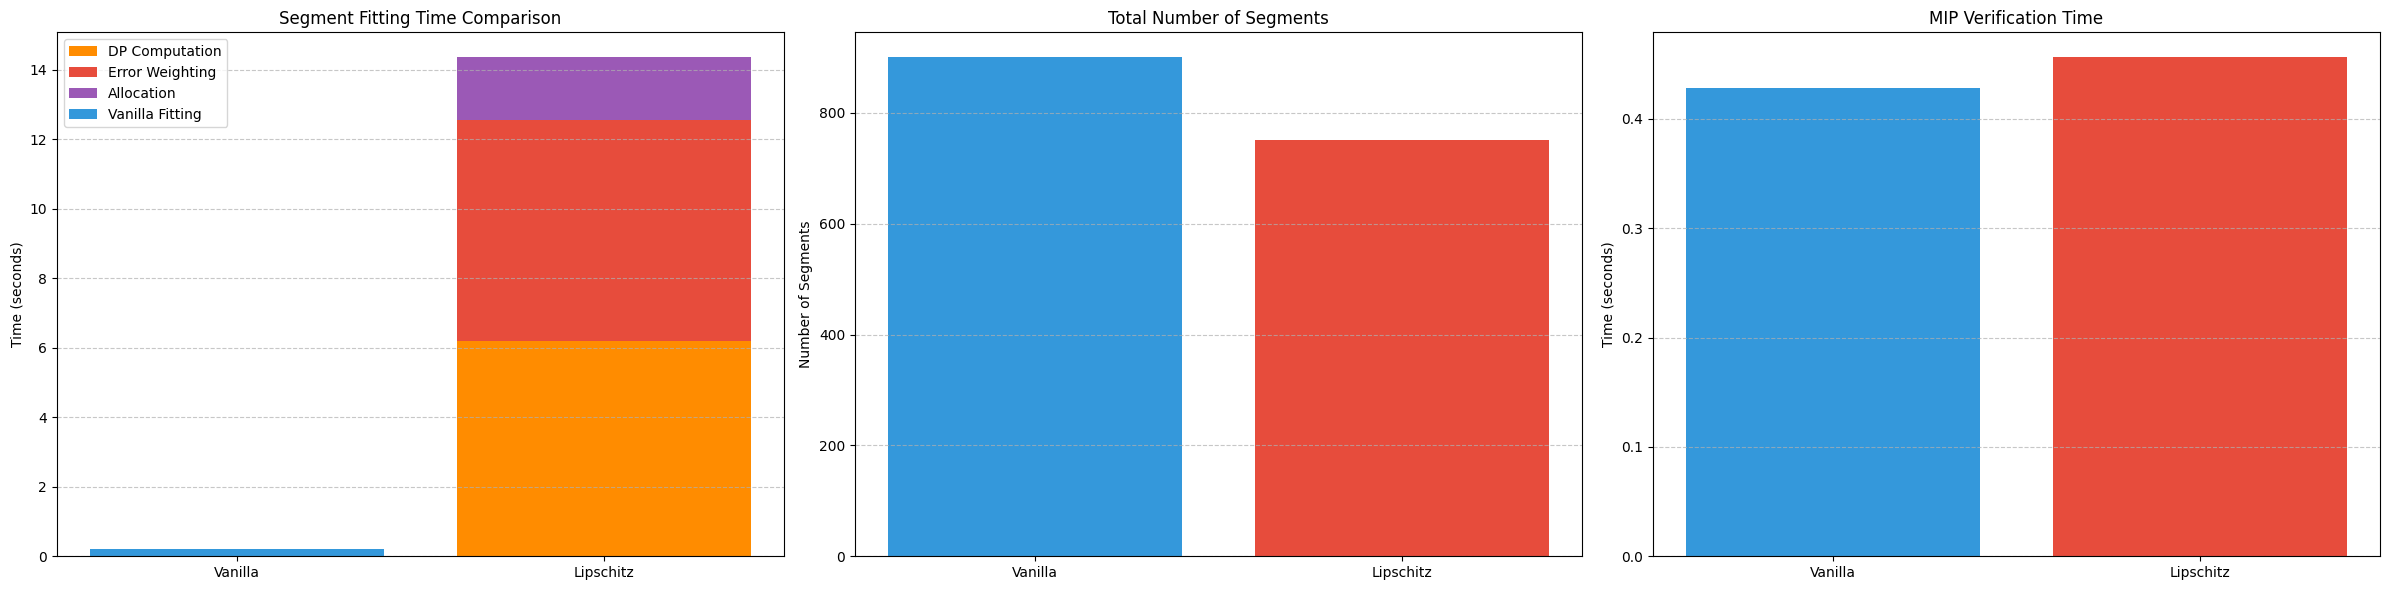

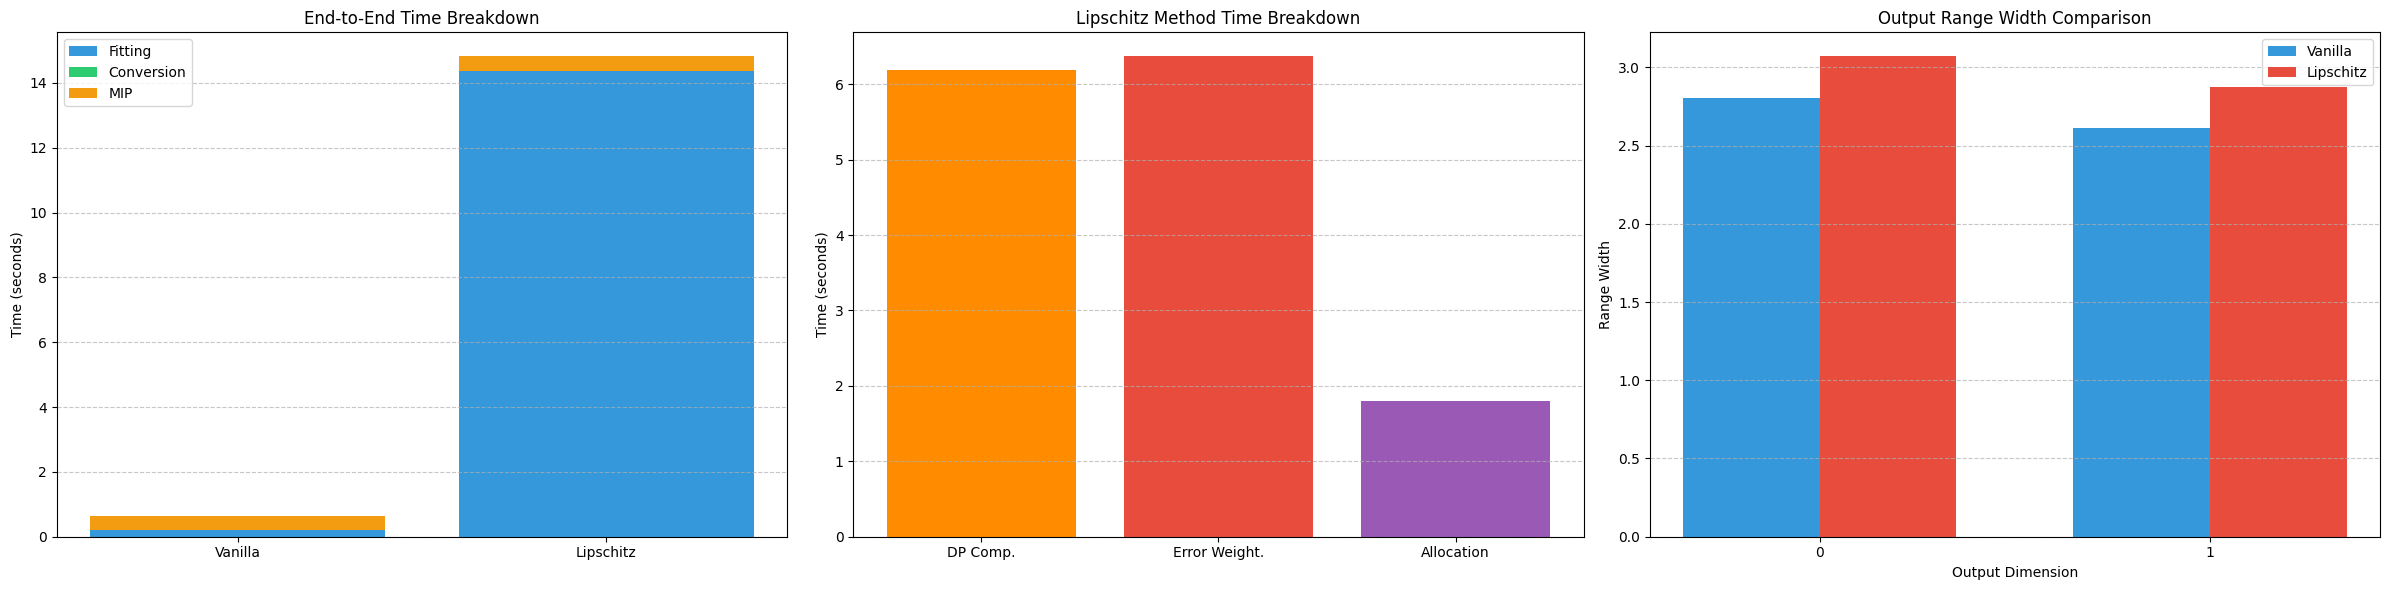

Results saved to output/4_15_2_range_experiment_20250521_170306/range_0p05
  - Console output: output/4_15_2_range_experiment_20250521_170306/range_0p05/output.md
  - Comparison chart: output/4_15_2_range_experiment_20250521_170306/range_0p05/output.png
  - Detailed metrics: output/4_15_2_range_experiment_20250521_170306/range_0p05/detailed_metrics.png

TIMEOUT: Iteration took 15.98 seconds, exceeding limit of 1 seconds

Iteration 1 complete: 15.98 seconds
  - Input Range: [-0.05, 0.05], Width: 0.1
  - Vanilla total time: 0.64 seconds
  - Lipschitz total time: 14.82 seconds
  - Maximum tightness: 5.75%

Experiment complete!
Results saved to: output/4_15_2_range_experiment_20250521_170306
Results overview:
 bound_width  vanilla_total_time  vanilla_max_tightness  lipschitz_total_time  lipschitz_max_tightness  timed_out
         0.1            0.637321               5.746344              14.82105                 5.221245       True


In [18]:
def run_kan_input_range_experiment(
    kan_model,
    starting_range=0.05,
    range_increment=0.05,
    max_range=1.0,
    timeout_seconds=600,
    segments_per_curve=5,
    output_root_dir=None,
    max_error_threshold=0.1,
    validate_bounds=True,
    num_validation_samples=5000,
    min_x=-5.0,
    max_x=5.0,
    seed=42
):
    input_dim = kan_model.layers[0].input_dim
    hidden_dim = kan_model.layers[0].output_dim  
    output_dim = kan_model.layers[-1].output_dim
    
    if output_root_dir is None:
        model_size = f"{input_dim}_{hidden_dim}_{output_dim}"
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_root_dir = os.path.join("output", f"{model_size}_range_experiment_{timestamp}")
    
    os.makedirs(output_root_dir, exist_ok=True)
    
    results_data = []
    
    current_range = starting_range
    iteration = 1
    timed_out = False
    constant = 2.5  
    
    lipschitz_max_segments = int(segments_per_curve * 3)  
    
    while current_range <= max_range and not timed_out:
        print(f"\n{'=' * 80}")
        print(f"ITERATION {iteration}: Testing with input range [-{current_range}, {current_range}]")
        print(f"{'=' * 80}")
        
        input_bounds = [(-current_range, current_range)] * input_dim
        
        range_str = f"{current_range:.2f}".replace('.', 'p')  
        iter_output_dir = os.path.join(output_root_dir, f"range_{range_str}")
        os.makedirs(iter_output_dir, exist_ok=True)
        
        iter_start_time = time.time()
        
        try:
            fitting_results = run_kan_fitting_only(
                kan_model=kan_model,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                max_error_threshold=max_error_threshold,
                vanilla_segments_per_curve=segments_per_curve,  
                max_segments_lipschitz=lipschitz_max_segments,
                min_x=min_x,
                max_x=max_x,
                seed=seed
            )
            
            verification_results, tightness_metrics = run_kan_verification_with_fitting(
                kan_model=kan_model,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                input_bounds=input_bounds,
                fitting_results=fitting_results,
                validate_bounds=validate_bounds,
                num_validation_samples=num_validation_samples,
                seed=seed,
                output_dir=iter_output_dir
            )
            
            total_time = time.time() - iter_start_time
            
            if total_time > timeout_seconds:
                print(f"\nTIMEOUT: Iteration took {total_time:.2f} seconds, exceeding limit of {timeout_seconds} seconds")
                timed_out = True
            
            vanilla_fit_time = fitting_results["vanilla"]["fit_time"]
            vanilla_verify_time = verification_results["verification"].get("vanilla_total_time", 0)
            vanilla_total_time = vanilla_fit_time + vanilla_verify_time
            
            lipschitz_fit_time = fitting_results["lipschitz"].get("total_fit_time", 0)
            lipschitz_verify_time = verification_results["verification"].get("lipschitz_total_time", 0)
            lipschitz_total_time = lipschitz_fit_time + lipschitz_verify_time
            
            max_tightness = tightness_metrics.get("max_tightness", 0)
            vanilla_max_tightness = tightness_metrics.get("vanilla_max_tightness", 0)
            lipschitz_max_tightness = tightness_metrics.get("lipschitz_max_tightness", 0)
            
            bound_width = 2 * current_range  
            
            result_entry = {
                "bound_width": bound_width,
                "input_range": current_range,
                "vanilla_fit_time": vanilla_fit_time,
                "vanilla_verify_time": vanilla_verify_time,
                "vanilla_total_time": vanilla_total_time,
                "vanilla_total_segments": fitting_results["vanilla"]["total_segments"],
                "vanilla_max_tightness": vanilla_max_tightness,
                "lipschitz_fit_time": lipschitz_fit_time,
                "lipschitz_verify_time": lipschitz_verify_time,
                "lipschitz_total_time": lipschitz_total_time,
                "lipschitz_total_segments": fitting_results["lipschitz"].get("total_segments", 0),
                "lipschitz_max_tightness": lipschitz_max_tightness,
                "max_tightness": max_tightness,
                "total_time": total_time,
                "timed_out": timed_out,
                "segments_per_curve": segments_per_curve  
            }
            
            results_data.append(result_entry)
            
            print(f"\nIteration {iteration} complete: {total_time:.2f} seconds")
            print(f"  - Input Range: [-{current_range}, {current_range}], Width: {bound_width}")
            print(f"  - Vanilla total time: {vanilla_total_time:.2f} seconds")
            print(f"  - Lipschitz total time: {lipschitz_total_time:.2f} seconds")
            print(f"  - Maximum tightness: {max_tightness:.2f}%")
            
        except Exception as e:
            print(f"ERROR in iteration {iteration}: {str(e)}")
            import traceback
            traceback.print_exc()
            
            result_entry = {
                "bound_width": 2 * current_range,
                "input_range": current_range,
                "error": str(e),
                "timed_out": False,
                "segments_per_curve": segments_per_curve
            }
            results_data.append(result_entry)
        
        current_range += range_increment
        iteration += 1
    
    results_df = pd.DataFrame(results_data)
    
    csv_path = os.path.join(output_root_dir, "experiment_results.csv")
    results_df.to_csv(csv_path, index=False)
    
    kan_verification_grapher.create_input_range_summary_plot(results_df, output_root_dir, segments_per_curve)
    
    return results_df, output_root_dir

def run_kan_fitting_only(
    kan_model, 
    input_dim: int,
    hidden_dim: int, 
    output_dim: int,
    max_error_threshold: float = 0.1,
    vanilla_segments_per_curve: int = 5,
    max_segments_lipschitz: int = 15,
    min_x: float = -5.0,
    max_x: float = 5.0,
    seed: int = 42,
) -> Dict[str, Any]:
    
    print("=" * 80)
    print("KAN SEGMENT FITTING SETTINGS")
    print("=" * 80)
    print(f"Input Dimensions: {input_dim}")
    print(f"Hidden Dimensions: {hidden_dim}")
    print(f"Output Dimensions: {output_dim}")
    print(f"Max Error Threshold: {max_error_threshold}")
    print(f"Vanilla Segments Per Curve: {vanilla_segments_per_curve}")
    print(f"Max Segments Lipschitz: {max_segments_lipschitz}")
    print(f"Min X: {min_x}")
    print(f"Max X: {max_x}")
    print(f"Random Seed: {seed}")
    
    print("=" * 80)
    print("RUNNING KAN SEGMENT FITTING")
    print("=" * 80)
    
    results = {
        "vanilla": {},
        "lipschitz": {}
    }
    
    
    print("\n" + "-" * 50)
    print("METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)")
    print("-" * 50)
    
    
    vanilla_start = time.time()
    vanilla_segments = fit_kan_vanilla(kan_model, segments_per_curve=vanilla_segments_per_curve, min_x=min_x, max_x=max_x)
    total_propagated_error, _, _ = compute_propagated_error(kan_model, vanilla_segments)
    max_error_threshold = total_propagated_error / 2
    print("Max Error Threshold Changed to: ", total_propagated_error / 2)
    vanilla_fit_time = time.time() - vanilla_start
    
    
    total_vanilla_segments = sum(len(segment_data['segments']) for segment_data in vanilla_segments)
    max_vanilla_error = max(segment_data['max_error'] for segment_data in vanilla_segments 
                          if np.isfinite(segment_data['max_error']))
    inf_error_count_vanilla = sum(1 for segment_data in vanilla_segments 
                                if not np.isfinite(segment_data['max_error']))
    
    
    results["vanilla"]["fit_time"] = vanilla_fit_time
    results["vanilla"]["total_segments"] = total_vanilla_segments
    results["vanilla"]["max_error"] = max_vanilla_error
    results["vanilla"]["inf_error_count"] = inf_error_count_vanilla
    results["vanilla"]["segments_data"] = vanilla_segments
    
    print(f"Vanilla Fitting Time: {vanilla_fit_time:.4f} seconds")
    print(f"Total Segments: {total_vanilla_segments}")
    print(f"Max Error: {max_vanilla_error:.6f}")
    print(f"Connections with Infinite Error: {inf_error_count_vanilla}")
    
    
    print("\n" + "-" * 50)
    print("METHOD 2: LIPSCHITZ-WEIGHTED FITTING")
    print("-" * 50)
    
    problem = False
    lipschitz_segments = None
    
    
    lipschitz_dp_start = time.time()
    try:
        
        error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(
            kan_model, min_x, max_x, max_segments_lipschitz
        )
        lipschitz_dp_time = time.time() - lipschitz_dp_start
        
        
        weighting_start = time.time()
        weighted_error_tables, _, _ = weight_dp_tables_lipschitz(
            kan_model, min_x, max_x, max_segments_lipschitz
        )
        weighting_time = time.time() - weighting_start
        
        
        allocation_start = time.time()
        optimal_allocation, actual_segments, total_lipschitz_segments, achieved_error, _, used_backup_allocation = fit_kan_optimally_lipschitz(
            weighted_error_tables, 
            segments_tables,
            max_error_threshold,
            max_segments=max_segments_lipschitz
        )
        allocation_time = time.time() - allocation_start
        
        
        lipschitz_segments = []
        for (layer_idx, input_idx, output_idx), num_segments in optimal_allocation.items():
            segments = actual_segments.get((layer_idx, input_idx, output_idx), [])
            max_error = error_tables.get((layer_idx, input_idx, output_idx), {}).get(num_segments, np.inf)
            lipschitz_segments.append({
                'layer_idx': layer_idx,
                'input_idx': input_idx,
                'output_idx': output_idx,
                'segments': segments,
                'max_error': max_error
            })
        
        
        lipschitz_fit_time = lipschitz_dp_time + weighting_time + allocation_time
        inf_error_count_lipschitz = sum(1 for segment_data in lipschitz_segments 
                                      if not np.isfinite(segment_data['max_error']))
        
        
        print("LIPSCHITZ ERROR: " + str(achieved_error if achieved_error is not None else "N/A"))
        results["lipschitz"]["dp_time"] = lipschitz_dp_time
        results["lipschitz"]["weighting_time"] = weighting_time
        results["lipschitz"]["allocation_time"] = allocation_time
        results["lipschitz"]["total_fit_time"] = lipschitz_fit_time
        results["lipschitz"]["total_segments"] = total_lipschitz_segments
        results["lipschitz"]["achieved_error"] = achieved_error
        results["lipschitz"]["inf_error_count"] = inf_error_count_lipschitz
        results["lipschitz"]["segments_data"] = lipschitz_segments
        
        print(f"Lipschitz DP Computation Time: {lipschitz_dp_time:.4f} seconds")
        print(f"Weighting Time: {weighting_time:.4f} seconds")
        print(f"Allocation Time: {allocation_time:.4f} seconds")
        print(f"Total Lipschitz Fitting Time: {lipschitz_fit_time:.4f} seconds")
        print(f"Total Segments: {total_lipschitz_segments}")
        print(f"Achieved Error: {achieved_error:.6f}")
        print(f"Connections with Infinite Error: {inf_error_count_lipschitz}")
    except Exception as e:
        print(f"ERROR: Lipschitz method failed: {str(e)}")
        results["lipschitz"]["error"] = str(e)
        
        lipschitz_segments = vanilla_segments  
    
    if problem:
        print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!WARNING: LIPSCHITZ error too small, used best possible error!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    else:
        print("\nLIPSCHITZ error was valid")
    
    return results

def calculate_tightness_metrics(results):
    metrics = {}
    
    if "validation" not in results or "sampled_min" not in results["validation"]:
        return metrics
    
    sampled_min = results["validation"]["sampled_min"]
    sampled_max = results["validation"]["sampled_max"]
    
    if "vanilla_results" in results["verification"]:
        vanilla_results = results["verification"]["vanilla_results"]
        vanilla_tightness = []
        
        for i in range(len(vanilla_results)):
            mip_min, mip_max = vanilla_results[i]
            samp_min, samp_max = sampled_min[i], sampled_max[i]
            
            mip_width = mip_max - mip_min
            sampled_width = samp_max - samp_min
            
            tightness = (sampled_width / mip_width * 100) if mip_width > 0 else 100.0
            vanilla_tightness.append(tightness)
        
        metrics["vanilla_tightness"] = vanilla_tightness
        metrics["vanilla_max_tightness"] = max(vanilla_tightness) if vanilla_tightness else 0
        metrics["vanilla_avg_tightness"] = sum(vanilla_tightness) / len(vanilla_tightness) if vanilla_tightness else 0
    
    if "lipschitz_results" in results["verification"]:
        lipschitz_results = results["verification"]["lipschitz_results"]
        lipschitz_tightness = []
        
        for i in range(len(lipschitz_results)):
            mip_min, mip_max = lipschitz_results[i]
            samp_min, samp_max = sampled_min[i], sampled_max[i]
            
            mip_width = mip_max - mip_min
            sampled_width = samp_max - samp_min
            
            tightness = (sampled_width / mip_width * 100) if mip_width > 0 else 100.0
            lipschitz_tightness.append(tightness)
        
        metrics["lipschitz_tightness"] = lipschitz_tightness
        metrics["lipschitz_max_tightness"] = max(lipschitz_tightness) if lipschitz_tightness else 0
        metrics["lipschitz_avg_tightness"] = sum(lipschitz_tightness) / len(lipschitz_tightness) if lipschitz_tightness else 0
    
    max_tightness = max(
        metrics.get("vanilla_max_tightness", 0),
        metrics.get("lipschitz_max_tightness", 0)
    )
    metrics["max_tightness"] = max_tightness
    
    return metrics

def run_kan_verification_with_fitting(
    kan_model,
    input_dim,
    hidden_dim,
    output_dim,
    input_bounds,
    fitting_results,
    time_limit_seconds=6000,
    validate_bounds=True,
    num_validation_samples=5000,
    abs_tol=1e-3,
    rel_tol=1e-2,
    seed=42,
    output_dir=None
):
    
    if output_dir is None:
        model_size = f"{input_dim}_{hidden_dim}_{output_dim}"
        if input_bounds:
            input_range = f"{input_bounds[0][0]}_{input_bounds[0][1]}"
            input_range = input_range.replace('-', 'neg')  
            input_range = input_range.replace('.', 'p')    
        else:
            input_range = "unknown"
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_dir = os.path.join("output", f"{model_size}_{input_range}_{timestamp}")
    
    
    os.makedirs(output_dir, exist_ok=True)
    
    original_stdout = sys.stdout
    output_md_path = os.path.join(output_dir, "output.md")
    
    class Tee:
        def __init__(self, *files):
            self.files = files
        
        def write(self, obj):
            for f in self.files:
                f.write(obj)
                f.flush()
        
        def flush(self):
            for f in self.files:
                f.flush()
    
    
    x_min_vec = [bound[0] for bound in input_bounds]
    x_max_vec = [bound[1] for bound in input_bounds]
    
    
    vanilla_segments = fitting_results["vanilla"]["segments_data"]
    if "error" not in fitting_results["lipschitz"]:
        lipschitz_segments = fitting_results["lipschitz"]["segments_data"]
        lipschitz_successful = True
    else:
        lipschitz_segments = vanilla_segments  
        lipschitz_successful = False
    
    
    results = {
        "vanilla": fitting_results["vanilla"],
        "lipschitz": fitting_results["lipschitz"],
        "verification": {},
        "validation": {}
    }
    
    with open(output_md_path, 'w') as f:
        
        sys.stdout = Tee(original_stdout, f)
        
        print("=" * 80)
        print("VERIFICATION SETTINGS")
        print("=" * 80)
        print(f"Input Bounds: {input_bounds}")
        print(f"Time Limit (seconds): {time_limit_seconds}")
        print(f"Validate Bounds: {validate_bounds}")
        print(f"Number of Validation Samples: {num_validation_samples}")
        print(f"Absolute Tolerance: {abs_tol}")
        print(f"Relative Tolerance: {rel_tol}")
        
        
        print("\n" + "-" * 50)
        print("VERIFICATION COMPARISON")
        print("-" * 50)
        
        lipschitz_all_bounds_valid = True
        vanilla_all_bounds_valid = True
        
        
        if lipschitz_successful:
            
            lipschitz_start_verify = time.time()
            print("\nConverting Lipschitz segments to verification format...")
            layer0_lipschitz, layer1_lipschitz = prep_segments_data(lipschitz_segments, input_dim, hidden_dim, output_dim)
            
            
            print("\nRunning MIP verification for Lipschitz segments...")
            lipschitz_verify_start = time.time()
            lipschitz_results = MIP_interval_analysis(layer0_lipschitz, layer1_lipschitz, x_min_vec, x_max_vec, M=1e4)
            lipschitz_verify_time = time.time() - lipschitz_verify_start
            total_lipschitz_time = time.time() - lipschitz_start_verify
            
            
            results["verification"]["lipschitz_conversion_time"] = lipschitz_verify_start - lipschitz_start_verify
            results["verification"]["lipschitz_mip_time"] = lipschitz_verify_time
            results["verification"]["lipschitz_total_time"] = total_lipschitz_time
            results["verification"]["lipschitz_results"] = lipschitz_results
            
            print(f"Lipschitz Verification Time: {lipschitz_verify_time:.4f} seconds")
            print(f"Lipschitz Total Time (conversion + verification): {total_lipschitz_time:.4f} seconds")
        
        
        vanilla_start_verify = time.time()
        print("\nConverting vanilla segments to verification format...")
        layer0_vanilla, layer1_vanilla = prep_segments_data(vanilla_segments, input_dim, hidden_dim, output_dim)
        
        
        print("\nRunning MIP verification for vanilla segments...")
        vanilla_verify_start = time.time()
        vanilla_results = MIP_interval_analysis(layer0_vanilla, layer1_vanilla, x_min_vec, x_max_vec, M=1e4)
        vanilla_verify_time = time.time() - vanilla_verify_start
        total_vanilla_time = time.time() - vanilla_start_verify
        
        
        results["verification"]["vanilla_conversion_time"] = vanilla_verify_start - vanilla_start_verify
        results["verification"]["vanilla_mip_time"] = vanilla_verify_time
        results["verification"]["vanilla_total_time"] = total_vanilla_time
        results["verification"]["vanilla_results"] = vanilla_results
        
        print(f"Vanilla Verification Time: {vanilla_verify_time:.4f} seconds")
        print(f"Vanilla Total Time (conversion + verification): {total_vanilla_time:.4f} seconds")
        
        
        if validate_bounds:
            print("\n" + "-" * 50)
            print("VALIDATING MIP BOUNDS")
            print("-" * 50)
            
            
            print(f"\nGenerating {num_validation_samples} validation samples...")
            validation_start = time.time()
            
            
            np.random.seed(seed)
            x_test_np = np.random.uniform(
                low=x_min_vec,
                high=x_max_vec,
                size=(num_validation_samples, input_dim)
            )
            x_test = torch.tensor(x_test_np, dtype=torch.float32)
            
            
            print("Running KAN model on validation samples...")
            with torch.no_grad():
                kan_model.eval()
                y_test = kan_model(x_test).detach().cpu().numpy()
            
            
            sampled_min = np.min(y_test, axis=0)
            sampled_max = np.max(y_test, axis=0)
            
            
            results["validation"]["x_samples"] = x_test_np
            results["validation"]["y_samples"] = y_test
            results["validation"]["sampled_min"] = sampled_min
            results["validation"]["sampled_max"] = sampled_max
            
            
            print("\nValidating vanilla MIP bounds...")
            vanilla_bound_checks = []
            vanilla_all_bounds_valid = True
            
            for o in range(output_dim):
                mip_min, mip_max = vanilla_results[o]
                samp_min, samp_max = sampled_min[o], sampled_max[o]
                
                print(f"Output {o}:")
                print(f"  MIP bounds:    [{mip_min:.6f}, {mip_max:.6f}]")
                print(f"  Sampled bounds: [{samp_min:.6f}, {samp_max:.6f}]")
                
                lower_ok, upper_ok, message = check_bounds(
                    mip_min, mip_max, samp_min, samp_max, abs_tol, rel_tol
                )
                
                bound_valid = lower_ok and upper_ok
                vanilla_all_bounds_valid = vanilla_all_bounds_valid and bound_valid
                vanilla_bound_checks.append({
                    "output_dim": o,
                    "mip_bounds": (mip_min, mip_max),
                    "sampled_bounds": (samp_min, samp_max),
                    "lower_valid": lower_ok,
                    "upper_valid": upper_ok,
                    "message": message,
                    "valid": bound_valid
                })
                
                if bound_valid:
                    print(f"  ✓ Bounds valid")
                else:
                    print(f"  ✗ Bounds invalid: {message}")
            
            results["validation"]["vanilla_bound_checks"] = vanilla_bound_checks
            results["validation"]["vanilla_all_bounds_valid"] = vanilla_all_bounds_valid
            
            if vanilla_all_bounds_valid:
                print("\n✓ All vanilla MIP bounds are valid")
            else:
                print("\n✗ Some vanilla MIP bounds are invalid")
            
            
            if lipschitz_successful:
                print("\nValidating Lipschitz MIP bounds...")
                lipschitz_bound_checks = []
                lipschitz_all_bounds_valid = True
                
                for o in range(output_dim):
                    mip_min, mip_max = lipschitz_results[o]
                    samp_min, samp_max = sampled_min[o], sampled_max[o]
                    
                    print(f"Output {o}:")
                    print(f"  MIP bounds:    [{mip_min:.6f}, {mip_max:.6f}]")
                    print(f"  Sampled bounds: [{samp_min:.6f}, {samp_max:.6f}]")
                    
                    lower_ok, upper_ok, message = check_bounds(
                        mip_min, mip_max, samp_min, samp_max, abs_tol, rel_tol
                    )
                    
                    bound_valid = lower_ok and upper_ok
                    lipschitz_all_bounds_valid = lipschitz_all_bounds_valid and bound_valid
                    lipschitz_bound_checks.append({
                        "output_dim": o,
                        "mip_bounds": (mip_min, mip_max),
                        "sampled_bounds": (samp_min, samp_max),
                        "lower_valid": lower_ok,
                        "upper_valid": upper_ok,
                        "message": message,
                        "valid": bound_valid
                    })
                    
                    if bound_valid:
                        print(f"  ✓ Bounds valid")
                    else:
                        print(f"  ✗ Bounds invalid: {message}")
                
                results["validation"]["lipschitz_bound_checks"] = lipschitz_bound_checks
                results["validation"]["lipschitz_all_bounds_valid"] = lipschitz_all_bounds_valid
                
                if lipschitz_all_bounds_valid:
                    print("\n✓ All Lipschitz MIP bounds are valid")
                else:
                    print("\n✗ Some Lipschitz MIP bounds are invalid")
        
        if not (lipschitz_all_bounds_valid and vanilla_all_bounds_valid):
            print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!WARNING: VERIFICATION FAILED FOR ONE OR BOTH METHODS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
        else:  
            print("\nVERIFICATION PASSED FOR BOTH METHODS")
    
    
    sys.stdout = original_stdout
    
    
    kan_verification_grapher.visualize_comparison_results(results, output_dir)
    kan_verification_grapher.detailed_metrics_visualization(results, output_dir)
    if validate_bounds and "create_relative_width_ratio_graph" in globals():
        kan_verification_grapher.create_relative_width_ratio_graph(results, output_dir)
    
    print(f"Results saved to {output_dir}")
    print(f"  - Console output: {output_md_path}")
    print(f"  - Comparison chart: {os.path.join(output_dir, 'output.png')}")
    print(f"  - Detailed metrics: {os.path.join(output_dir, 'detailed_metrics.png')}")
    
    
    tightness_metrics = calculate_tightness_metrics(results) if validate_bounds else {}
    
    return results, tightness_metrics

results_df, output_dir = run_kan_input_range_experiment(
    kan_model=kan_duffing,
    starting_range=0.05,        
    range_increment=0.1,       
    max_range=4.5,              
    timeout_seconds=10, # Usually timeout_seconds is ~4000 for paper tests
    segments_per_curve=10,       
    validate_bounds=True,       
    num_validation_samples=5000
)

print(f"\nExperiment complete!")
print(f"Results saved to: {output_dir}")
print(f"Results overview:")
print(results_df[["bound_width", "vanilla_total_time", "vanilla_max_tightness", 
                    "lipschitz_total_time", "lipschitz_max_tightness", "timed_out"]].to_string(index=False))

# Varying Bound Tightness


ITERATION 3: Testing with 20 segments
KAN SEGMENT FITTING SETTINGS
Input Dimensions: 4
Hidden Dimensions: 15
Output Dimensions: 2
Max Error Threshold: 0.1
Vanilla Segments Per Curve: 20
Max Segments Lipschitz: 75
Min X: -5.0
Max X: 5.0
Random Seed: 42
RUNNING KAN SEGMENT FITTING

--------------------------------------------------
METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)
--------------------------------------------------
Fitting Layer 0 (4 -> 15)
Fitting Layer 1 (15 -> 2)
Generated data for 90 connections.
Max Error Threshold Changed to:  0.011368540926655337
Vanilla Fitting Time: 0.2381 seconds
Total Segments: 1800
Max Error: 0.019588
Connections with Infinite Error: 0

--------------------------------------------------
METHOD 2: LIPSCHITZ-WEIGHTED FITTING
--------------------------------------------------
Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs
Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs
Weighing La

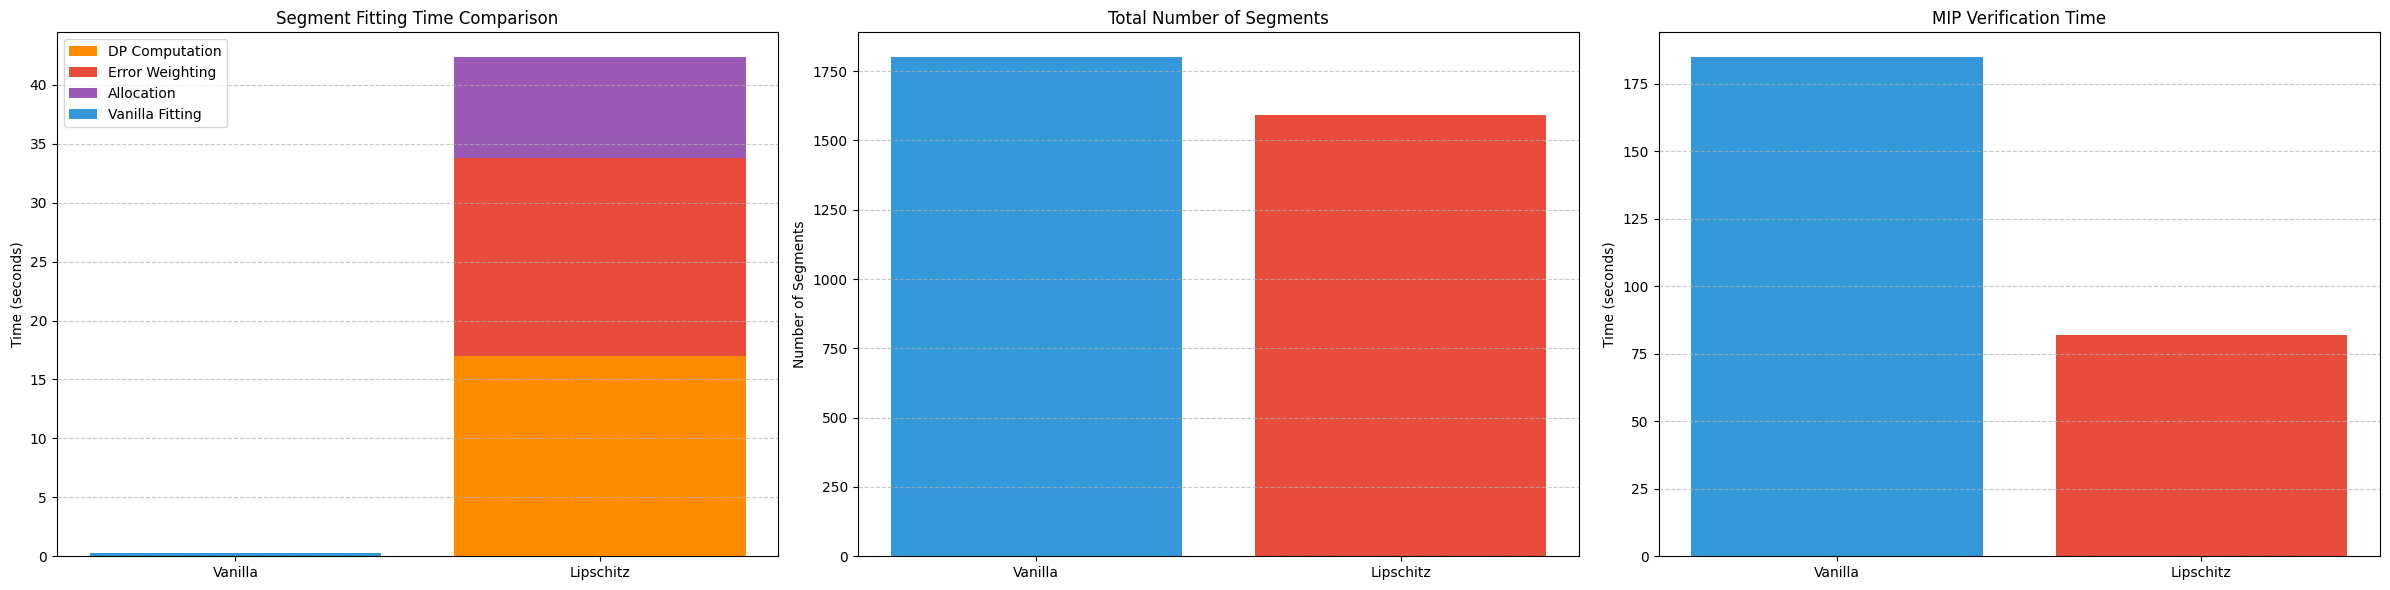

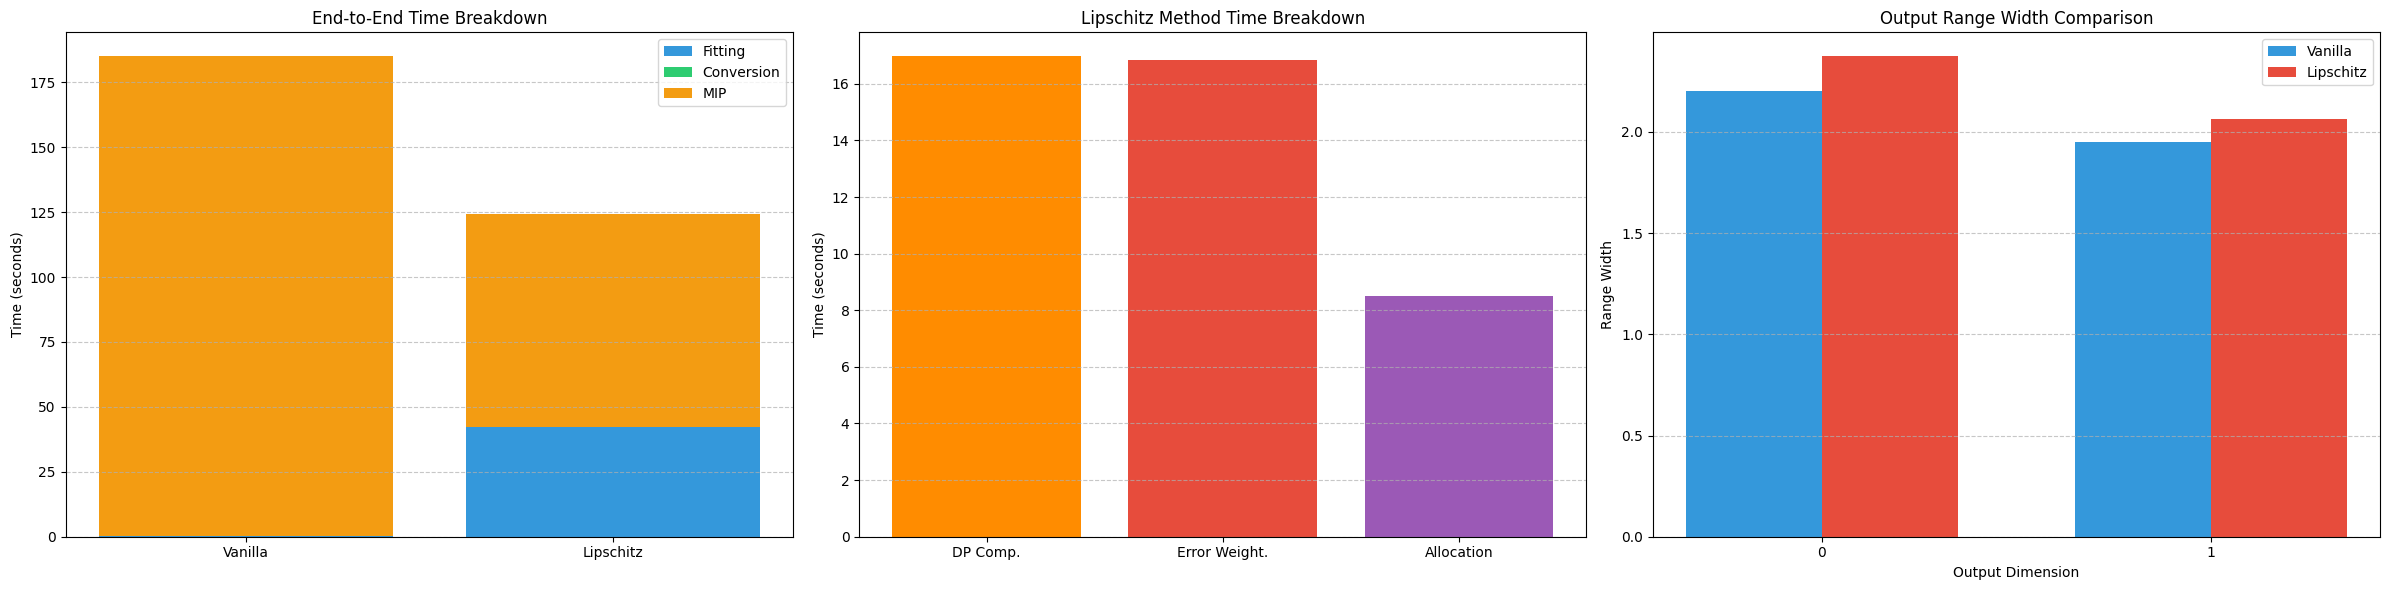

Results saved to output/4_15_2_neg0p5_0p5_20250521_175157/segments_20
  - Console output: output/4_15_2_neg0p5_0p5_20250521_175157/segments_20/output.md
  - Comparison chart: output/4_15_2_neg0p5_0p5_20250521_175157/segments_20/output.png
  - Detailed metrics: output/4_15_2_neg0p5_0p5_20250521_175157/segments_20/detailed_metrics.png

TIMEOUT: Iteration took 309.77 seconds, exceeding limit of 10 seconds

Iteration 3 complete: 309.77 seconds
  - Vanilla total time: 185.02 seconds
  - Lipschitz total time: 124.23 seconds
  - Maximum tightness: 69.77%

Experiment complete!
Results saved to: output/4_15_2_neg0p5_0p5_20250521_175157
Results overview:
 segments  vanilla_total_time  vanilla_max_tightness  lipschitz_total_time  lipschitz_max_tightness  timed_out
       20          185.020986               69.77012            124.231254                65.903588       True


In [30]:
def run_kan_adaptive_experiment(
    kan_model,
    input_bounds,
    timeout_seconds,
    starting_segments=3,
    segment_increment=5,
    max_segments=10,
    output_root_dir=None,
    max_error_threshold=0.1,
    validate_bounds=True,
    num_validation_samples=5000,
    min_x=-5.0,
    max_x=5.0,
    seed=42
):
    input_dim = kan_model.layers[0].input_dim
    hidden_dim = kan_model.layers[0].output_dim  
    output_dim = kan_model.layers[-1].output_dim
    
    if output_root_dir is None:
        model_size = f"{input_dim}_{hidden_dim}_{output_dim}"
        if input_bounds:
            input_range = f"{input_bounds[0][0]}_{input_bounds[0][1]}"
            input_range = input_range.replace('-', 'neg')  
            input_range = input_range.replace('.', 'p')    
        else:
            input_range = "unknown"
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_root_dir = os.path.join("output", f"{model_size}_{input_range}_{timestamp}")
    
    os.makedirs(output_root_dir, exist_ok=True)
    
    results_data = []
    
    segments = starting_segments
    iteration = 3
    timed_out = False
    constant = 2.5
    while segments <= max_segments and not timed_out:
        print(f"\n{'=' * 80}")
        print(f"ITERATION {iteration}: Testing with {segments} segments")
        print(f"{'=' * 80}")
        
        iter_output_dir = os.path.join(output_root_dir, f"segments_{segments}")
        os.makedirs(iter_output_dir, exist_ok=True)
        
        iter_start_time = time.time()
        
        try:
            lipschitz_max_segments = int(segments * 3 * (iteration + 0.4)**0.185)
            constant = constant * 2 * (iteration + 0.4)**0.075
            
            fitting_results = run_kan_fitting_only(
                kan_model=kan_model,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                max_error_threshold=max_error_threshold,
                vanilla_segments_per_curve=segments,
                max_segments_lipschitz=lipschitz_max_segments,
                min_x=min_x,
                max_x=max_x,
                seed=seed,
            )
            
            verification_results, tightness_metrics = run_kan_verification_with_fitting(
                kan_model=kan_model,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                input_bounds=input_bounds,
                fitting_results=fitting_results,
                validate_bounds=validate_bounds,
                num_validation_samples=num_validation_samples,
                seed=seed,
                output_dir=iter_output_dir
            )
            
            total_time = time.time() - iter_start_time
            
            if total_time > timeout_seconds:
                print(f"\nTIMEOUT: Iteration took {total_time:.2f} seconds, exceeding limit of {timeout_seconds} seconds")
                timed_out = True
            
            vanilla_fit_time = fitting_results["vanilla"]["fit_time"]
            vanilla_verify_time = verification_results["verification"].get("vanilla_total_time", 0)
            vanilla_total_time = vanilla_fit_time + vanilla_verify_time
            
            lipschitz_fit_time = fitting_results["lipschitz"].get("total_fit_time", 0)
            lipschitz_verify_time = verification_results["verification"].get("lipschitz_total_time", 0)
            lipschitz_total_time = lipschitz_fit_time + lipschitz_verify_time
            
            max_tightness = tightness_metrics.get("max_tightness", 0)
            vanilla_max_tightness = tightness_metrics.get("vanilla_max_tightness", 0)
            lipschitz_max_tightness = tightness_metrics.get("lipschitz_max_tightness", 0)
            
            result_entry = {
                "segments": segments,
                "vanilla_fit_time": vanilla_fit_time,
                "vanilla_verify_time": vanilla_verify_time,
                "vanilla_total_time": vanilla_total_time,
                "vanilla_total_segments": fitting_results["vanilla"]["total_segments"],
                "vanilla_max_tightness": vanilla_max_tightness,
                "lipschitz_fit_time": lipschitz_fit_time,
                "lipschitz_verify_time": lipschitz_verify_time,
                "lipschitz_total_time": lipschitz_total_time,
                "lipschitz_total_segments": fitting_results["lipschitz"].get("total_segments", 0),
                "lipschitz_max_tightness": lipschitz_max_tightness,
                "max_tightness": max_tightness,
                "total_time": total_time,
                "timed_out": timed_out
            }
            
            results_data.append(result_entry)
            
            print(f"\nIteration {iteration} complete: {total_time:.2f} seconds")
            print(f"  - Vanilla total time: {vanilla_total_time:.2f} seconds")
            print(f"  - Lipschitz total time: {lipschitz_total_time:.2f} seconds")
            print(f"  - Maximum tightness: {max_tightness:.2f}%")
            
        except Exception as e:
            print(f"ERROR in iteration {iteration}: {str(e)}")
            import traceback
            traceback.print_exc()
            
            result_entry = {
                "segments": segments,
                "error": str(e),
                "timed_out": False
            }
            results_data.append(result_entry)
        
        segments += segment_increment
        iteration += 1
    
    results_df = pd.DataFrame(results_data)
    
    csv_path = os.path.join(output_root_dir, "experiment_results.csv")
    results_df.to_csv(csv_path, index=False)
    
    kan_verification_grapher.create_experiment_summary_plot(results_df, output_root_dir)
    
    return results_df, output_root_dir



input_bounds = [(-0.5, 0.5)] * model.layers[0].input_dim
results_df, output_dir = run_kan_adaptive_experiment(
    kan_model=kan_duffing,
    input_bounds=input_bounds,
    timeout_seconds=10, # Usually timeout_seconds is ~4000 for paper tests
    starting_segments=20, # Start at 3 segments for paper tests
    segment_increment=1,  
    max_segments=30,      
    validate_bounds=True, 
    num_validation_samples=5000
)

print(f"\nExperiment complete!")
print(f"Results saved to: {output_dir}")
print(f"Results overview:")
print(results_df[["segments", "vanilla_total_time", "vanilla_max_tightness", 
                    "lipschitz_total_time", "lipschitz_max_tightness", "timed_out"]].to_string(index=False))